In [23]:
import data_profiling
from data_profiling import ProfileReport
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
ruta = Path("data/REHAB/Rehab_exercise/d02_processed_data")

# ------------------------------------------------------------
# Canales según el artículo
# ------------------------------------------------------------

canales_1 = [
    "pitch1",
    "yaw1",
    "roll1",
    "pitch2",
    "yaw2",
    "roll2"
]

canales_2 = [
    "f1",
    "f2",
    "f3",
    "f4",
    "f5",
    "pitch3"
]

estadisticas = [
    "mean",
    "std",
    "median",
    "min",
    "max",
    "range",
    "iqr",
    "rms",
    "energy",
    "mad_diff"
]


# ------------------------------------------------------------
# Función para extraer features de una señal 1D
# ------------------------------------------------------------

def extraer_features(x):

    q25 = np.percentile(x, 25)
    q75 = np.percentile(x, 75)

    diffs = np.diff(x)

    return {
        "mean": np.mean(x),
        "std": np.std(x),
        "median": np.median(x),
        "min": np.min(x),
        "max": np.max(x),
        "range": np.max(x) - np.min(x),
        "iqr": q75 - q25,
        "rms": np.sqrt(np.mean(x ** 2)),
        "energy": np.sum(x ** 2),
        "mad_diff": np.mean(np.abs(diffs))
    }


# ------------------------------------------------------------
# Construcción del DataFrame
# ------------------------------------------------------------

filas = []

# Movimientos 000 a 015, ignorando 014
movimientos = [
    f"{i:03d}"
    for i in range(16)
    if i != 14
]

for movimiento in movimientos:

    archivo_1 = ruta / f"{movimiento}_1.npy"
    archivo_2 = ruta / f"{movimiento}_2.npy"

    # --------------------------------------------------------
    # Validar existencia
    # --------------------------------------------------------

    if not archivo_1.exists():
        print(f"No existe: {archivo_1.name}")
        continue

    if not archivo_2.exists():
        print(f"No existe: {archivo_2.name}")
        continue

    # --------------------------------------------------------
    # Cargar ambos sensores
    # --------------------------------------------------------

    try:
        datos_1 = np.load(archivo_1)
        datos_2 = np.load(archivo_2)

    except Exception as e:
        print(f"Error en movimiento {movimiento}: {e}")
        continue

    # Esperamos:
    # datos_1 -> (n_muestras, 880, 6)
    # datos_2 -> (n_muestras, 880, 6)

    if datos_1.ndim != 3 or datos_2.ndim != 3:
        print(
            f"{movimiento}: dimensiones inesperadas "
            f"{datos_1.shape}, {datos_2.shape}"
        )
        continue

    # --------------------------------------------------------
    # Verificar que correspondan las mismas muestras
    # --------------------------------------------------------

    if datos_1.shape[0] != datos_2.shape[0]:
        print(
            f"ERROR {movimiento}: diferente número de muestras "
            f"_1={datos_1.shape[0]}, _2={datos_2.shape[0]}"
        )
        continue

    if datos_1.shape[1] != datos_2.shape[1]:
        print(
            f"ERROR {movimiento}: diferente número de tiempos "
            f"_1={datos_1.shape[1]}, _2={datos_2.shape[1]}"
        )
        continue

    if datos_1.shape[2] != 6 or datos_2.shape[2] != 6:
        print(
            f"ERROR {movimiento}: se esperaban 6 canales por archivo"
        )
        continue

    n_muestras = datos_1.shape[0]

    print(
        f"{movimiento}: {n_muestras} muestras "
        f"| _1 {datos_1.shape} "
        f"| _2 {datos_2.shape}"
    )

    # --------------------------------------------------------
    # Cada índice rep corresponde a la MISMA muestra
    # en _1 y _2
    # --------------------------------------------------------

    for rep in range(n_muestras):

        muestra_1 = datos_1[rep]  # (880, 6)
        muestra_2 = datos_2[rep]  # (880, 6)

        fila = {
            "movimiento": movimiento,
        }

        # ----------------------------------------------------
        # Features de *_1.npy
        # ----------------------------------------------------

        for i, canal in enumerate(canales_1):

            x = muestra_1[:, i]

            features = extraer_features(x)

            for nombre_stat, valor in features.items():
                fila[f"{canal}_{nombre_stat}"] = valor

        # ----------------------------------------------------
        # Features de *_2.npy
        # ----------------------------------------------------

        for i, canal in enumerate(canales_2):

            x = muestra_2[:, i]

            features = extraer_features(x)

            for nombre_stat, valor in features.items():
                fila[f"{canal}_{nombre_stat}"] = valor

        filas.append(fila)


# ------------------------------------------------------------
# DataFrame final
# ------------------------------------------------------------

df_eda = pd.DataFrame(filas)

df_eda["movimiento"] = (
    df_eda["movimiento"]
    .astype("category")
)

print("\n" + "=" * 60)
print("RESULTADO FINAL")
print("=" * 60)

print("Shape:", df_eda.shape)

print(
    "Número de muestras:",
    len(df_eda)
)

print(
    "Número de movimientos:",
    df_eda["movimiento"].nunique()
)

print(
    "Número de features numéricas:",
    df_eda.select_dtypes(
        include=np.number
    ).shape[1]  # quitamos repeticion
)

display(df_eda.head())

000: 232 muestras | _1 (232, 880, 6) | _2 (232, 880, 6)
001: 212 muestras | _1 (212, 880, 6) | _2 (212, 880, 6)
002: 267 muestras | _1 (267, 880, 6) | _2 (267, 880, 6)
003: 250 muestras | _1 (250, 880, 6) | _2 (250, 880, 6)
004: 287 muestras | _1 (287, 880, 6) | _2 (287, 880, 6)
005: 293 muestras | _1 (293, 880, 6) | _2 (293, 880, 6)
006: 260 muestras | _1 (260, 880, 6) | _2 (260, 880, 6)
007: 385 muestras | _1 (385, 880, 6) | _2 (385, 880, 6)
008: 299 muestras | _1 (299, 880, 6) | _2 (299, 880, 6)
009: 307 muestras | _1 (307, 880, 6) | _2 (307, 880, 6)
010: 311 muestras | _1 (311, 880, 6) | _2 (311, 880, 6)
011: 235 muestras | _1 (235, 880, 6) | _2 (235, 880, 6)
012: 293 muestras | _1 (293, 880, 6) | _2 (293, 880, 6)
013: 313 muestras | _1 (313, 880, 6) | _2 (313, 880, 6)
015: 313 muestras | _1 (313, 880, 6) | _2 (313, 880, 6)

RESULTADO FINAL
Shape: (4257, 121)
Número de muestras: 4257
Número de movimientos: 15
Número de features numéricas: 120


,movimiento,pitch1_mean,pitch1_std,pitch1_median,pitch1_min,pitch1_max,pitch1_range,pitch1_iqr,pitch1_rms,pitch1_energy,...,pitch3_mean,pitch3_std,pitch3_median,pitch3_min,pitch3_max,pitch3_range,pitch3_iqr,pitch3_rms,pitch3_energy,pitch3_mad_diff
0,000,-1.033517e-15,34.772806,3.836009,-51.937941,55.319659,107.2576,66.771200,34.772806,1.064050e+06,...,-3.100550e-15,77.233940,-14.801629,-95.283864,117.690851,212.974715,157.818933,77.233940,5.249272e+06,2.658525
1,000,-1.033517e-15,35.467788,-0.734184,-50.565684,60.505916,111.0716,69.738875,35.467788,1.107008e+06,...,1.033517e-15,78.282052,-14.213077,-93.939868,115.247023,209.186891,161.612773,78.282052,5.392710e+06,2.528120
2,000,-5.167584e-16,35.799498,1.143317,-51.339183,59.732417,111.0716,69.656225,35.799498,1.127812e+06,...,1.033517e-15,76.947035,-18.287711,-84.622759,116.411515,201.034275,159.317074,76.947035,5.210345e+06,2.499150
3,000,-5.813531e-16,28.824225,7.182024,-57.703826,60.696474,118.4003,44.573275,28.824225,7.311356e+05,...,1.033517e-15,87.527223,-47.022745,-144.676239,128.995333,273.671572,180.201959,87.527223,6.741693e+06,5.230356
4,000,-3.875688e-16,28.850607,9.440611,-59.756789,58.643511,118.4003,41.780500,28.850607,7.324746e+05,...,-5.167584e-15,87.141703,-34.596055,-147.631461,126.040111,273.671572,178.924120,87.141703,6.682435e+06,5.419122


In [ ]:
profile = ProfileReport(df_eda, title="Profiling Report")
profile.to_file("eda3.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 121/121 [00:01<00:00, 103.59it/s]
d:\ANACONDA\Lib\site-packages\data_profiling\model\pandas\duplicates_pandas.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index(name=duplicates_key)
d:\ANACONDA\Lib\site-packages\data_profiling\model\pandas\duplicates_pandas.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index(name=duplicates_key)
d:\ANACONDA\Lib\site-packages\data_profiling\model\pandas\duplicates_pandas.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the r

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [3]:
df_eda.to_csv("data/df_eda.csv", index=False)

In [5]:
df_eda.describe(include="all")

,movimiento,pitch1_mean,pitch1_std,pitch1_median,pitch1_min,pitch1_max,pitch1_range,pitch1_iqr,pitch1_rms,pitch1_energy,...,pitch3_mean,pitch3_std,pitch3_median,pitch3_min,pitch3_max,pitch3_range,pitch3_iqr,pitch3_rms,pitch3_energy,pitch3_mad_diff
count,4257,4.257000e+03,4257.000000,4257.000000,4257.000000,4257.000000,4257.000000,4257.000000,4257.000000,4.257000e+03,...,4.257000e+03,4257.000000,4257.000000,4257.000000,4257.000000,4257.000000,4257.000000,4257.000000,4.257000e+03,4257.000000
unique,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1.075856e-16,18.793499,-0.228707,-31.102382,33.694662,64.797044,30.237777,18.793499,4.499467e+05,...,-1.693146e-16,51.604746,-2.671901,-89.236468,95.087908,184.324376,80.765280,51.604746,3.497760e+06,2.740821
std,NaN,2.831837e-15,12.575554,9.047510,20.365189,25.311176,39.798017,24.776739,12.575554,4.440707e+05,...,5.846967e-15,36.221347,26.457240,68.334203,68.144531,119.404426,71.246083,36.221347,3.938008e+06,2.595079
min,NaN,-1.937844e-14,0.000000,-36.649255,-107.539847,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,-3.720660e-14,0.000000,-139.052783,-338.993265,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,NaN,-9.043271e-16,5.794126,-3.582551,-45.264331,11.759706,25.233700,8.008675,5.794126,2.954327e+04,...,-2.067033e-15,21.033859,-14.527107,-131.688039,35.613348,86.685650,11.439675,21.033859,3.893324e+05,0.481929
50%,NaN,0.000000e+00,19.595393,-0.019179,-31.248741,29.543040,65.743500,24.755400,19.595393,3.379019e+05,...,0.000000e+00,52.472842,-0.288255,-80.279543,97.637403,181.621891,73.237757,52.472842,2.422991e+06,2.170599
75%,NaN,1.033517e-15,29.522952,3.542093,-12.330360,50.342620,94.386000,49.636025,29.522952,7.670121e+05,...,2.067033e-15,76.021151,8.843620,-38.207036,141.366715,294.587969,132.536024,76.021151,5.085710e+06,4.259335


In [6]:
canales = canales_1 + canales_2

comprobacion = []

for canal in canales:
    mean_col = f"{canal}_mean"
    std_col = f"{canal}_std"
    min_col = f"{canal}_min"
    max_col = f"{canal}_max"
    range_col = f"{canal}_range"
    rms_col = f"{canal}_rms"
    energy_col = f"{canal}_energy"

    comprobacion.append({
        "canal": canal,

        "max_abs_mean":
            df_eda[mean_col].abs().max(),

        "max_diferencia_std_rms":
            (df_eda[std_col] - df_eda[rms_col])
            .abs()
            .max(),

        "max_error_energy":
            (
                df_eda[energy_col]
                - 880 * df_eda[rms_col] ** 2
            )
            .abs()
            .max(),

        "max_error_range":
            (
                df_eda[range_col]
                - (
                    df_eda[max_col]
                    - df_eda[min_col]
                )
            )
            .abs()
            .max()
    })

comprobacion = pd.DataFrame(comprobacion)

display(comprobacion)

,canal,max_abs_mean,max_diferencia_std_rms,max_error_energy,max_error_range
0,pitch1,1.937844e-14,1.421085e-14,4.656613e-10,0.0
1,yaw1,2.893847e-14,2.842171e-14,1.490116e-08,0.0
2,roll1,3.307253e-14,2.842171e-14,1.490116e-08,0.0
3,pitch2,3.100550e-14,1.421085e-14,4.656613e-10,0.0
4,yaw2,1.446923e-14,1.421085e-14,7.450581e-09,0.0
5,roll2,1.653627e-14,1.421085e-14,7.450581e-09,0.0
6,f1,2.858320e-14,1.421085e-14,4.656613e-10,0.0
7,f2,3.307253e-14,1.421085e-14,4.656613e-10,0.0
8,f3,2.612859e-14,1.421085e-14,4.656613e-10,0.0
9,f4,2.409386e-14,1.421085e-14,4.656613e-10,0.0


In [7]:
feature_cols = df_eda.select_dtypes(
    include=np.number
).columns.tolist()

diagnostico_columnas = pd.DataFrame({
    "caracteristica": feature_cols,
    "n_unicos": [
        df_eda[col].nunique(dropna=True)
        for col in feature_cols
    ],
    "std": [
        df_eda[col].std()
        for col in feature_cols
    ],
    "min": [
        df_eda[col].min()
        for col in feature_cols
    ],
    "max": [
        df_eda[col].max()
        for col in feature_cols
    ],
    "faltantes": [
        df_eda[col].isna().sum()
        for col in feature_cols
    ]
})

diagnostico_columnas["rango"] = (
    diagnostico_columnas["max"]
    - diagnostico_columnas["min"]
)

display(
    diagnostico_columnas
    .sort_values(["n_unicos", "std"])
    .head(30)
)

,caracteristica,n_unicos,std,min,max,faltantes,rango
10,yaw1_mean,239,2.331501e-15,-2.893847e-14,2.893847e-14,0,5.787694e-14
20,roll1_mean,239,2.573948e-15,-3.307253e-14,2.842171e-14,0,6.149424e-14
50,roll2_mean,253,1.231554e-15,-1.653627e-14,1.111030e-14,0,2.764657e-14
40,yaw2_mean,253,1.515391e-15,-1.240220e-14,1.446923e-14,0,2.687143e-14
0,pitch1_mean,419,2.831837e-15,-1.937844e-14,1.750519e-14,0,3.688363e-14
110,pitch3_mean,558,5.846967e-15,-3.720660e-14,3.836931e-14,0,7.557591e-14
30,pitch2_mean,577,3.912070e-15,-3.100550e-14,2.170385e-14,0,5.270935e-14
80,f3_mean,877,3.303207e-15,-2.428764e-14,2.612859e-14,0,5.041624e-14
100,f5_mean,880,3.195426e-15,-3.342781e-14,2.583792e-14,0,5.926572e-14
70,f2_mean,893,3.555858e-15,-2.348021e-14,3.307253e-14,0,5.655274e-14


In [8]:
columnas_constantes = diagnostico_columnas.loc[
    diagnostico_columnas["n_unicos"] <= 1,
    "caracteristica"
].tolist()

columnas_casi_constantes = diagnostico_columnas.loc[
    diagnostico_columnas["std"] < 1e-10,
    "caracteristica"
].tolist()

print("Constantes:")
print(columnas_constantes)

print("\nPrácticamente constantes:")
print(columnas_casi_constantes)

Constantes:
[]

Prácticamente constantes:
['pitch1_mean', 'yaw1_mean', 'roll1_mean', 'pitch2_mean', 'yaw2_mean', 'roll2_mean', 'f1_mean', 'f2_mean', 'f3_mean', 'f4_mean', 'f5_mean', 'pitch3_mean']


In [9]:
muestras_sin_variacion = []

for canal in canales:

    col_range = f"{canal}_range"

    n_ceros = np.isclose(
        df_eda[col_range],
        0,
        atol=1e-12
    ).sum()

    muestras_sin_variacion.append({
        "canal": canal,
        "muestras_range_cero": n_ceros,
        "porcentaje": (
            100 * n_ceros / len(df_eda)
        )
    })

muestras_sin_variacion = pd.DataFrame(
    muestras_sin_variacion
).sort_values(
    "porcentaje",
    ascending=False
)

display(muestras_sin_variacion)

,canal,muestras_range_cero,porcentaje
5,roll2,77,1.808786
0,pitch1,74,1.738313
1,yaw1,74,1.738313
2,roll1,74,1.738313
3,pitch2,74,1.738313
4,yaw2,74,1.738313
6,f1,68,1.597369
7,f2,68,1.597369
8,f3,68,1.597369
9,f4,68,1.597369


In [10]:
range_cero_por_movimiento = []

for canal in canales:

    temporal = df_eda[
        ["movimiento", f"{canal}_range"]
    ].copy()

    temporal["range_cero"] = np.isclose(
        temporal[f"{canal}_range"],
        0,
        atol=1e-12
    )

    resumen = (
        temporal
        .groupby(
            "movimiento",
            observed=True
        )["range_cero"]
        .agg(["sum", "mean"])
        .reset_index()
    )

    resumen["canal"] = canal
    resumen["porcentaje"] = (
        100 * resumen["mean"]
    )

    range_cero_por_movimiento.append(
        resumen[
            [
                "movimiento",
                "canal",
                "sum",
                "porcentaje"
            ]
        ]
    )

range_cero_por_movimiento = pd.concat(
    range_cero_por_movimiento,
    ignore_index=True
)

display(
    range_cero_por_movimiento.sort_values(
        "porcentaje",
        ascending=False
    ).head(40)
)

,movimiento,canal,sum,porcentaje
161,011,f5,16,6.808511
176,011,pitch3,16,6.808511
41,011,roll1,16,6.808511
71,011,yaw2,16,6.808511
26,011,yaw1,16,6.808511
116,011,f2,16,6.808511
86,011,roll2,16,6.808511
131,011,f3,16,6.808511
11,011,pitch1,16,6.808511
56,011,pitch2,16,6.808511


In [11]:
muestras_nulas_por_canal = []

for canal in canales:

    mascara = (
        np.isclose(
            df_eda[f"{canal}_std"],
            0,
            atol=1e-12
        )
        &
        np.isclose(
            df_eda[f"{canal}_min"],
            0,
            atol=1e-12
        )
        &
        np.isclose(
            df_eda[f"{canal}_max"],
            0,
            atol=1e-12
        )
    )

    muestras_nulas_por_canal.append({
        "canal": canal,
        "muestras_nulas": mascara.sum(),
        "porcentaje": (
            100 * mascara.mean()
        )
    })

muestras_nulas_por_canal = pd.DataFrame(
    muestras_nulas_por_canal
).sort_values(
    "porcentaje",
    ascending=False
)

display(muestras_nulas_por_canal)

,canal,muestras_nulas,porcentaje
5,roll2,77,1.808786
0,pitch1,74,1.738313
1,yaw1,74,1.738313
2,roll1,74,1.738313
3,pitch2,74,1.738313
4,yaw2,74,1.738313
6,f1,68,1.597369
7,f2,68,1.597369
8,f3,68,1.597369
9,f4,68,1.597369


In [12]:
canales = canales_1 + canales_2

estadisticas_conservar = [
    "std",
    "median",
    "min",
    "max",
    "iqr",
    "mad_diff"
]

estadisticas_redundantes = [
    "mean",
    "range",
    "rms",
    "energy"
]

features_reducidas = [
    f"{canal}_{stat}"
    for canal in canales
    for stat in estadisticas_conservar
]

df_eda_reducido = df_eda[
    ["movimiento"] + features_reducidas
].copy()

print("DataFrame original:", df_eda.shape)
print("DataFrame reducido:", df_eda_reducido.shape)

print(
    "Características numéricas conservadas:",
    len(features_reducidas)
)

display(df_eda_reducido.head())

DataFrame original: (4257, 121)
DataFrame reducido: (4257, 73)
Características numéricas conservadas: 72


,movimiento,pitch1_std,pitch1_median,pitch1_min,pitch1_max,pitch1_iqr,pitch1_mad_diff,yaw1_std,yaw1_median,yaw1_min,...,f5_min,f5_max,f5_iqr,f5_mad_diff,pitch3_std,pitch3_median,pitch3_min,pitch3_max,pitch3_iqr,pitch3_mad_diff
0,000,34.772806,3.836009,-51.937941,55.319659,66.771200,0.926939,10.918033,-0.550008,-23.928708,...,-9.245568,6.354432,4.700,0.198294,77.233940,-14.801629,-95.283864,117.690851,157.818933,2.658525
1,000,35.467788,-0.734184,-50.565684,60.505916,69.738875,0.937843,11.170478,-0.308406,-22.792656,...,-10.137955,5.562045,3.600,0.200796,78.282052,-14.213077,-93.939868,115.247023,161.612773,2.528120
2,000,35.799498,1.143317,-51.339183,59.732417,69.656225,0.954751,11.059709,-0.066234,-23.796384,...,-10.562500,5.837500,3.200,0.197497,76.947035,-18.287711,-84.622759,116.411515,159.317074,2.499150
3,000,28.824225,7.182024,-57.703826,60.696474,44.573275,2.138616,22.996796,-6.643711,-61.371511,...,-12.218750,15.181250,4.625,0.303641,87.527223,-47.022745,-144.676239,128.995333,180.201959,5.230356
4,000,28.850607,9.440611,-59.756789,58.643511,41.780500,2.194652,23.969877,-7.491328,-61.384678,...,-10.229545,15.570455,4.500,0.291354,87.141703,-34.596055,-147.631461,126.040111,178.924120,5.419122


In [34]:
df_eda_reducido.to_csv("data/df_eda_reducido.csv", index=False)

In [15]:
resumen_univariado = (
    df_eda_reducido[features_reducidas]
    .describe()
    .T
)

resumen_univariado["rango_total"] = (
    resumen_univariado["max"]
    - resumen_univariado["min"]
)

resumen_univariado["iqr_describe"] = (
    resumen_univariado["75%"]
    - resumen_univariado["25%"]
)

resumen_univariado["coeficiente_variacion"] = (
    resumen_univariado["std"]
    / resumen_univariado["mean"].abs()
        .replace(0, np.nan)
)

display(resumen_univariado)

,count,mean,std,min,25%,50%,75%,max,rango_total,iqr_describe,coeficiente_variacion
pitch1_std,4257.0,18.793499,12.575554,0.000000,5.794126,19.595393,29.522952,51.905153,51.905153,23.728826,0.669144
pitch1_median,4257.0,-0.228707,9.047510,-36.649255,-3.582551,-0.019179,3.542093,32.418440,69.067695,7.124644,39.559390
pitch1_min,4257.0,-31.102382,20.365189,-107.539847,-45.264331,-31.248741,-12.330360,0.000000,107.539847,32.933971,0.654779
pitch1_max,4257.0,33.694662,25.311176,0.000000,11.759706,29.543040,50.342620,125.636420,125.636420,38.582913,0.751192
pitch1_iqr,4257.0,30.237777,24.776739,0.000000,8.008675,24.755400,49.636025,105.239525,105.239525,41.627350,0.819397
...,...,...,...,...,...,...,...,...,...,...,...
pitch3_median,4257.0,-2.671901,26.457240,-139.052783,-14.527107,-0.288255,8.843620,146.123468,285.176251,23.370727,9.902029
pitch3_min,4257.0,-89.236468,68.334203,-338.993265,-131.688039,-80.279543,-38.207036,0.000000,338.993265,93.481003,0.765765
pitch3_max,4257.0,95.087908,68.144531,0.000000,35.613348,97.637403,141.366715,348.485187,348.485187,105.753367,0.716648
pitch3_iqr,4257.0,80.765280,71.246083,0.000000,11.439675,73.237757,132.536024,353.100711,353.100711,121.096349,0.882138


In [16]:
resumen_univariado["asimetria"] = (
    df_eda_reducido[features_reducidas]
    .skew()
)

resumen_univariado["curtosis"] = (
    df_eda_reducido[features_reducidas]
    .kurtosis()
)

resumen_univariado["porcentaje_ceros"] = [
    100 * np.isclose(
        df_eda_reducido[col],
        0,
        atol=1e-12
    ).mean()
    for col in features_reducidas
]

resumen_univariado = (
    resumen_univariado
    .sort_values(
        "asimetria",
        key=lambda x: x.abs(),
        ascending=False
    )
)

display(
    resumen_univariado[
        [
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max",
            "asimetria",
            "curtosis",
            "porcentaje_ceros"
        ]
    ].head(25)
)

,mean,std,min,25%,50%,75%,max,asimetria,curtosis,porcentaje_ceros
roll2_max,28.920555,36.049393,0.000000,7.653542,18.713093,40.707620,864.701551,7.451320,121.244712,1.808786
yaw2_max,40.037221,46.583745,0.000000,8.489481,28.519860,60.192751,870.005863,6.580750,93.683180,1.738313
f1_mad_diff,0.128912,0.147615,0.000000,0.050967,0.087031,0.166212,1.945051,6.319973,62.283068,1.597369
roll1_min,-52.719529,57.421075,-847.345237,-70.783306,-43.354721,-17.997304,0.000000,-5.422825,52.402768,1.738313
yaw1_min,-46.202619,57.154635,-807.693846,-62.452358,-31.344694,-14.261576,0.000000,-5.280852,47.243104,1.738313
yaw2_min,-36.889105,40.125435,-606.185914,-52.512266,-27.712418,-8.355660,0.000000,-4.378236,45.843142,1.738313
roll2_std,12.265587,13.446179,0.000000,3.340548,9.098269,17.074459,189.279549,4.073037,34.130117,1.808786
roll2_min,-28.763132,33.662628,-459.069270,-36.518876,-19.683490,-8.278538,0.000000,-3.903123,29.439095,1.808786
f1_max,9.071009,11.759386,0.000000,2.248864,6.476818,11.057955,100.386591,3.718121,18.217002,1.597369
f5_mad_diff,0.181502,0.172840,0.000000,0.069625,0.137770,0.234130,2.094425,3.261113,20.239672,1.597369


In [17]:
def separar_nombre_feature(nombre):

    for stat in sorted(
        estadisticas_conservar,
        key=len,
        reverse=True
    ):
        sufijo = f"_{stat}"

        if nombre.endswith(sufijo):
            canal = nombre[:-len(sufijo)]
            return canal, stat

    return None, None

In [18]:
nombres_separados = [
    separar_nombre_feature(nombre)
    for nombre in resumen_univariado.index
]

resumen_univariado[
    ["canal", "estadistica"]
] = pd.DataFrame(
    nombres_separados,
    index=resumen_univariado.index
)

display(
    resumen_univariado[
        [
            "canal",
            "estadistica",
            "mean",
            "std",
            "asimetria",
            "curtosis",
            "porcentaje_ceros"
        ]
    ].head()
)

,canal,estadistica,mean,std,asimetria,curtosis,porcentaje_ceros
roll2_max,roll2,max,28.920555,36.049393,7.451320,121.244712,1.808786
yaw2_max,yaw2,max,40.037221,46.583745,6.580750,93.683180,1.738313
f1_mad_diff,f1,mad_diff,0.128912,0.147615,6.319973,62.283068,1.597369
roll1_min,roll1,min,-52.719529,57.421075,-5.422825,52.402768,1.738313
yaw1_min,yaw1,min,-46.202619,57.154635,-5.280852,47.243104,1.738313


In [19]:
resumen_por_estadistica = (
    resumen_univariado
    .groupby("estadistica")
    .agg(
        desviacion_promedio=("std", "mean"),
        asimetria_media=("asimetria", "mean"),
        asimetria_maxima=("asimetria", lambda x: x.abs().max()),
        curtosis_media=("curtosis", "mean"),
        porcentaje_ceros_promedio=("porcentaje_ceros", "mean")
    )
    .sort_values(
        "asimetria_maxima",
        ascending=False
    )
)

display(resumen_por_estadistica)

,desviacion_promedio,asimetria_media,asimetria_maxima,curtosis_media,porcentaje_ceros_promedio
estadistica,,,,,
max,27.550422,2.662354,7.451320,23.699089,1.673714
mad_diff,0.712632,2.474270,6.319973,12.045784,1.673714
min,29.876465,-2.823794,5.422825,18.967820,1.673714
std,14.639720,2.075795,4.073037,11.514064,1.673714
iqr,26.511504,2.090343,3.227412,8.614406,7.315402
median,9.332090,0.469736,1.630146,9.245679,1.681544


In [24]:
def graficar_histogramas_estadistica(
    df,
    estadistica,
    bins=35
):
    fig, axes = plt.subplots(
        3,
        4,
        figsize=(18, 12)
    )

    axes = axes.flatten()

    for ax, canal in zip(axes, canales):

        columna = f"{canal}_{estadistica}"

        sns.histplot(
            data=df,
            x=columna,
            bins=bins,
            kde=True,
            ax=ax,
            color="steelblue"
        )

        ax.set_title(columna)
        ax.set_xlabel("")
        ax.set_ylabel("Frecuencia")

    plt.suptitle(
        f"Distribuciones de {estadistica}",
        fontsize=16,
        y=1.01
    )

    plt.tight_layout()
    plt.show()

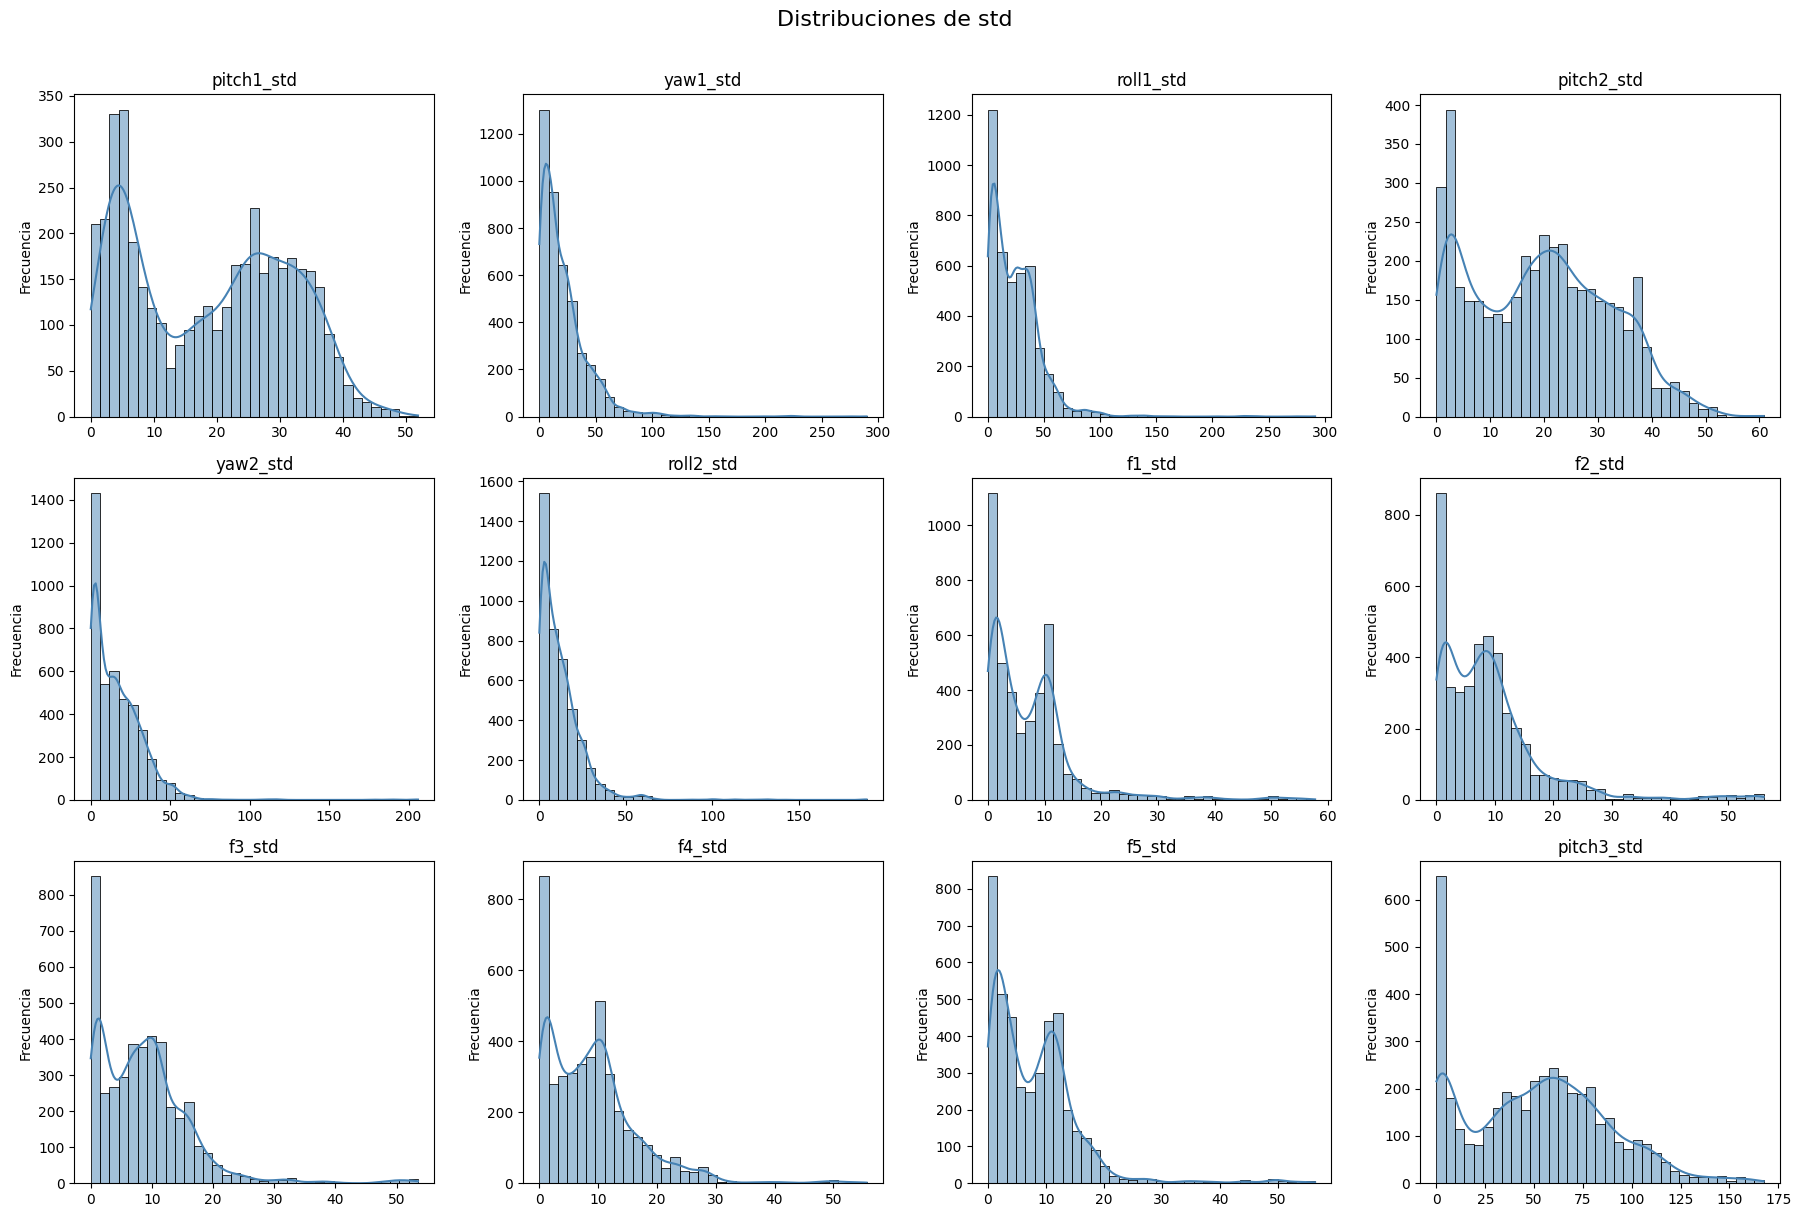

In [25]:
graficar_histogramas_estadistica(
    df_eda_reducido,
    "std"
)

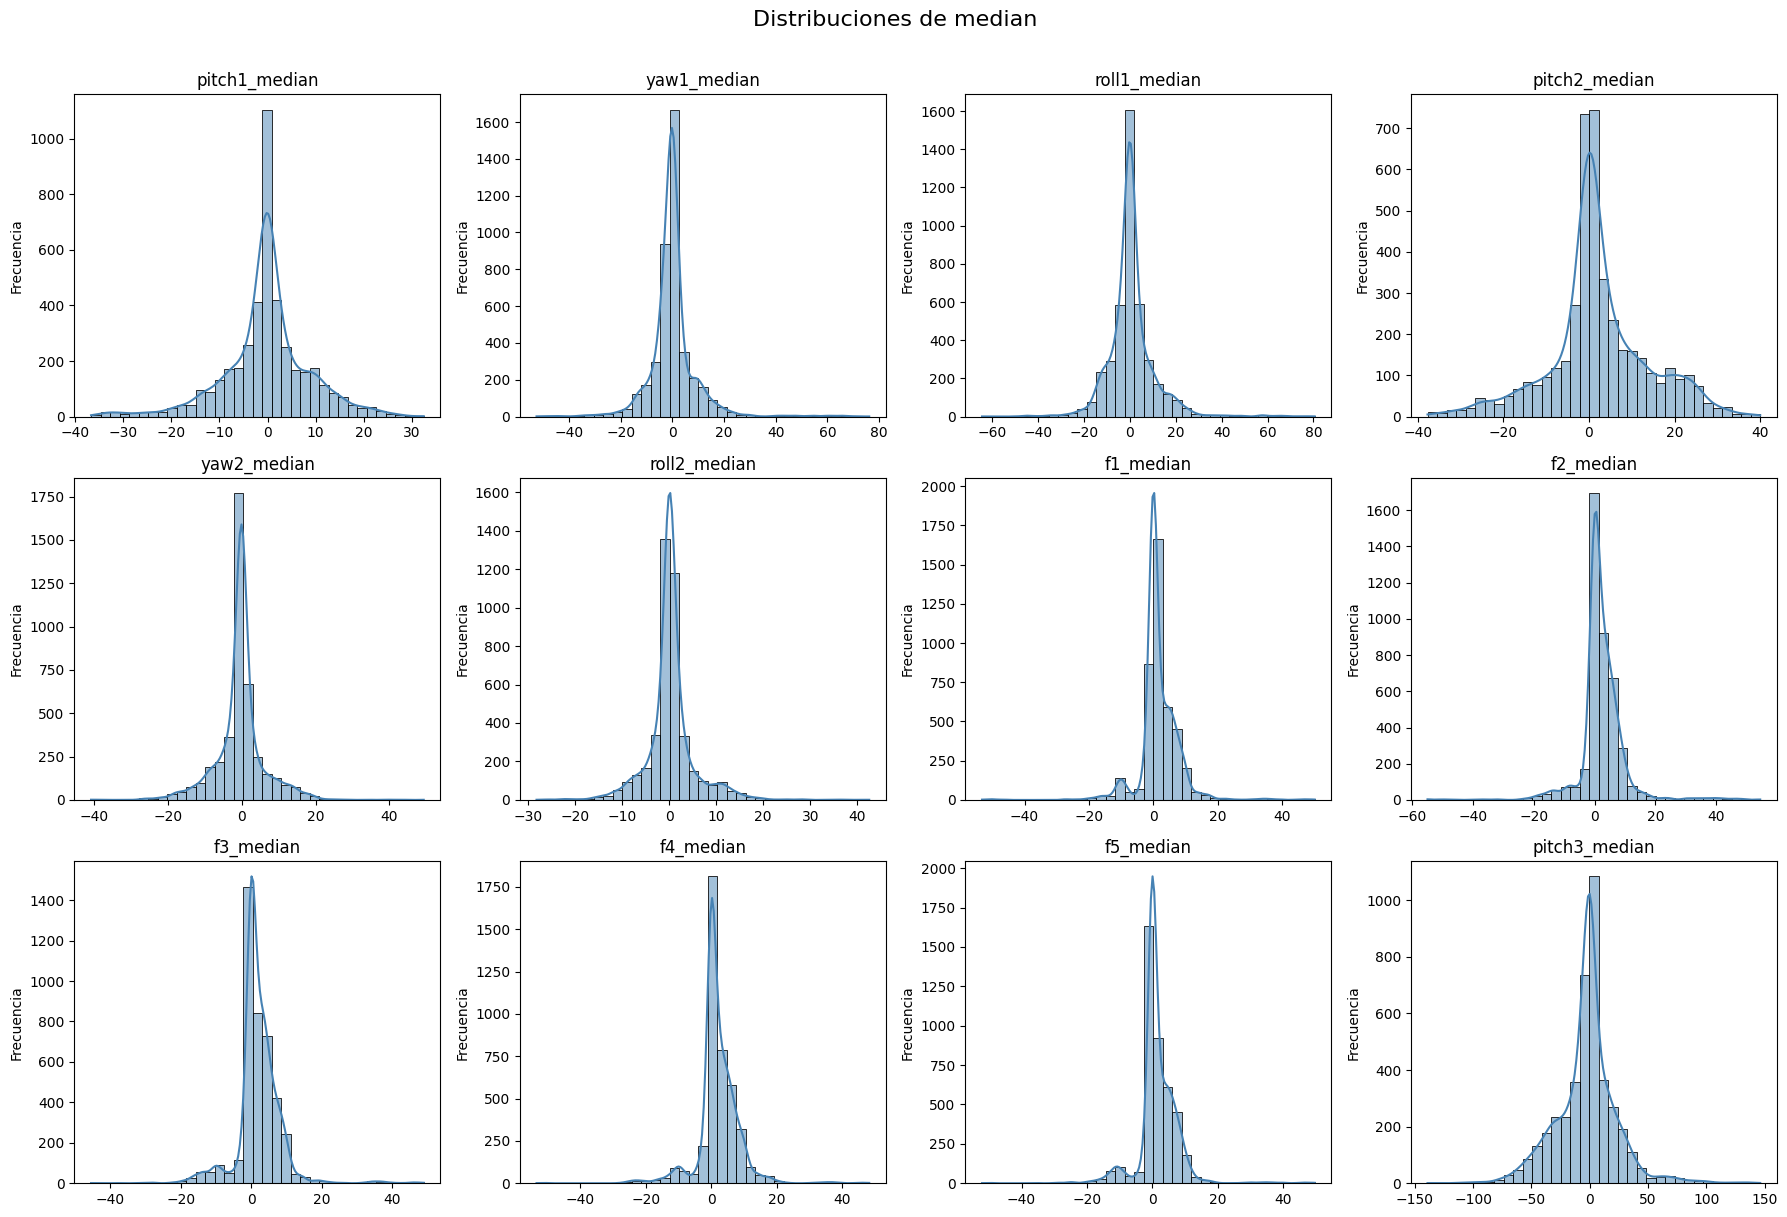

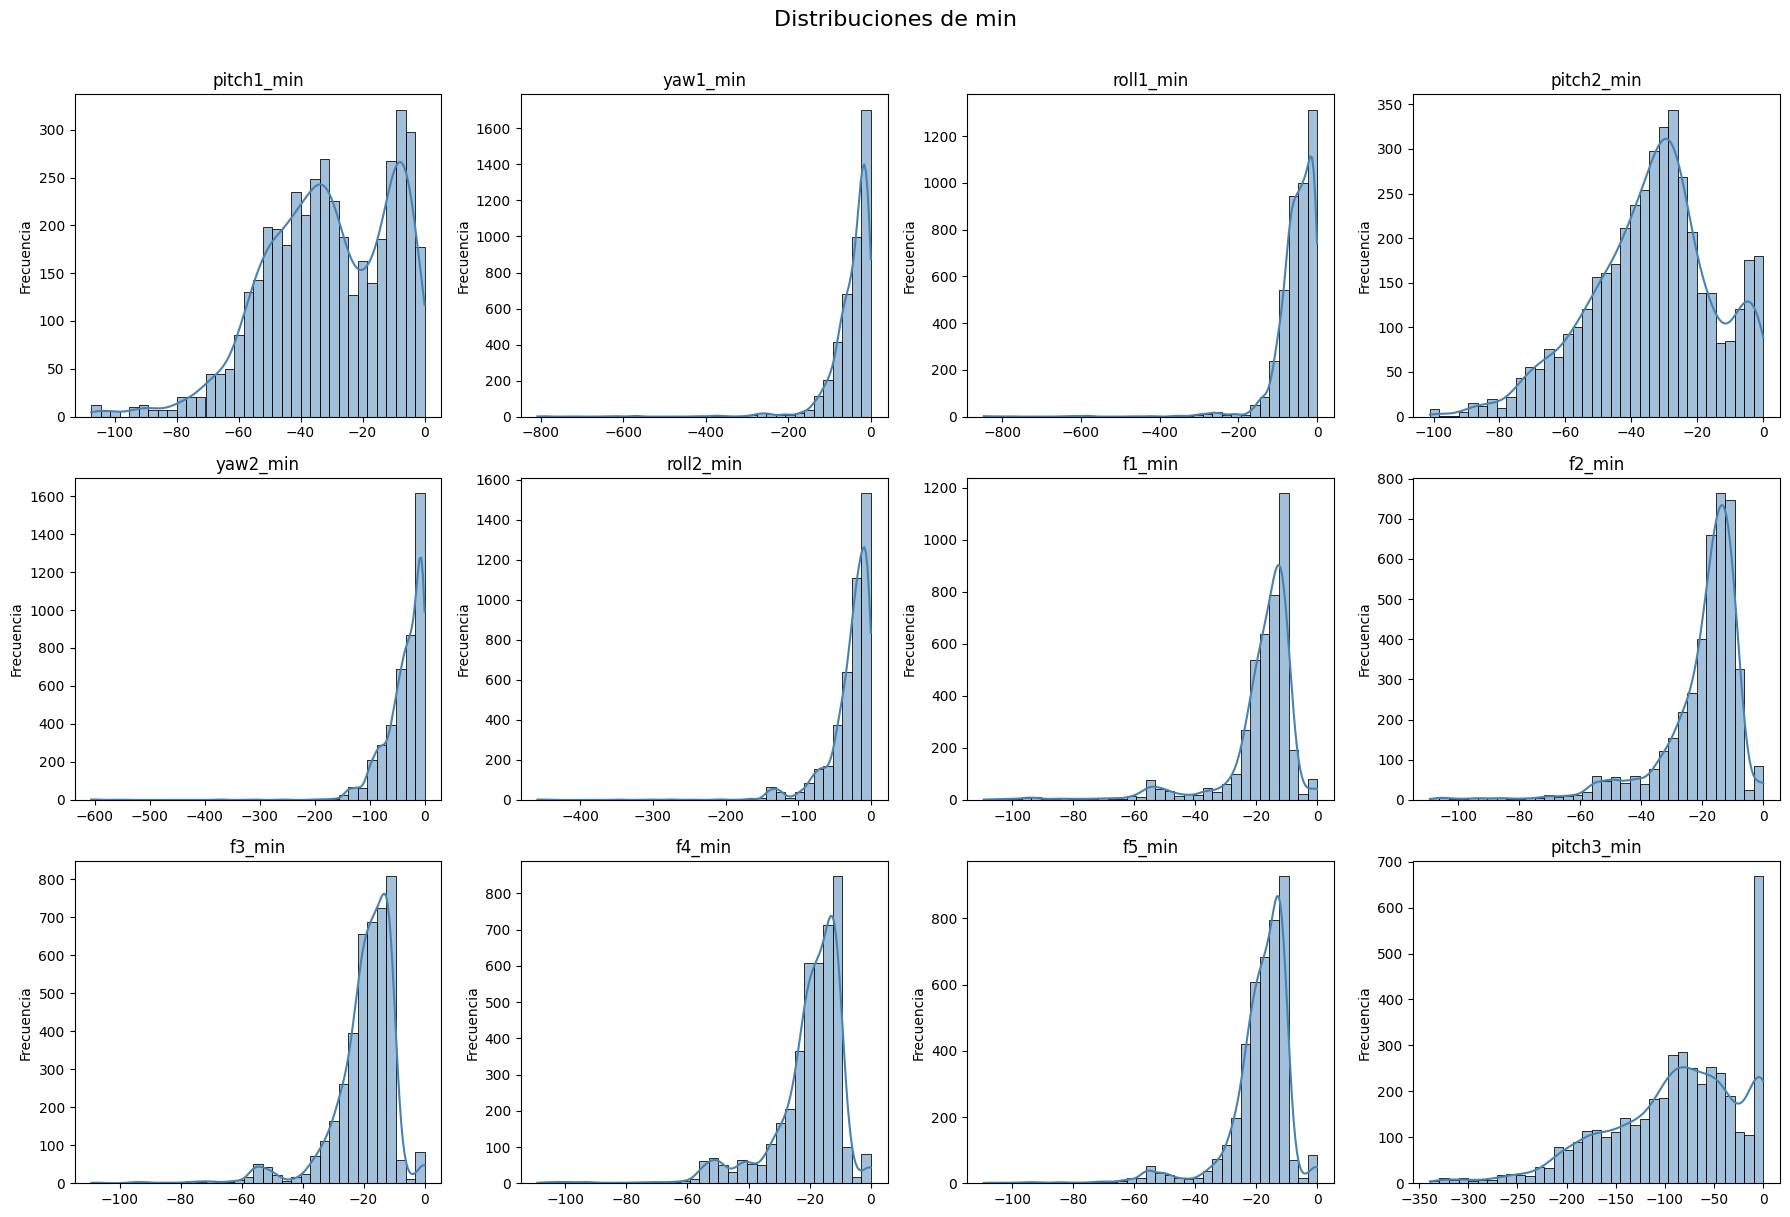

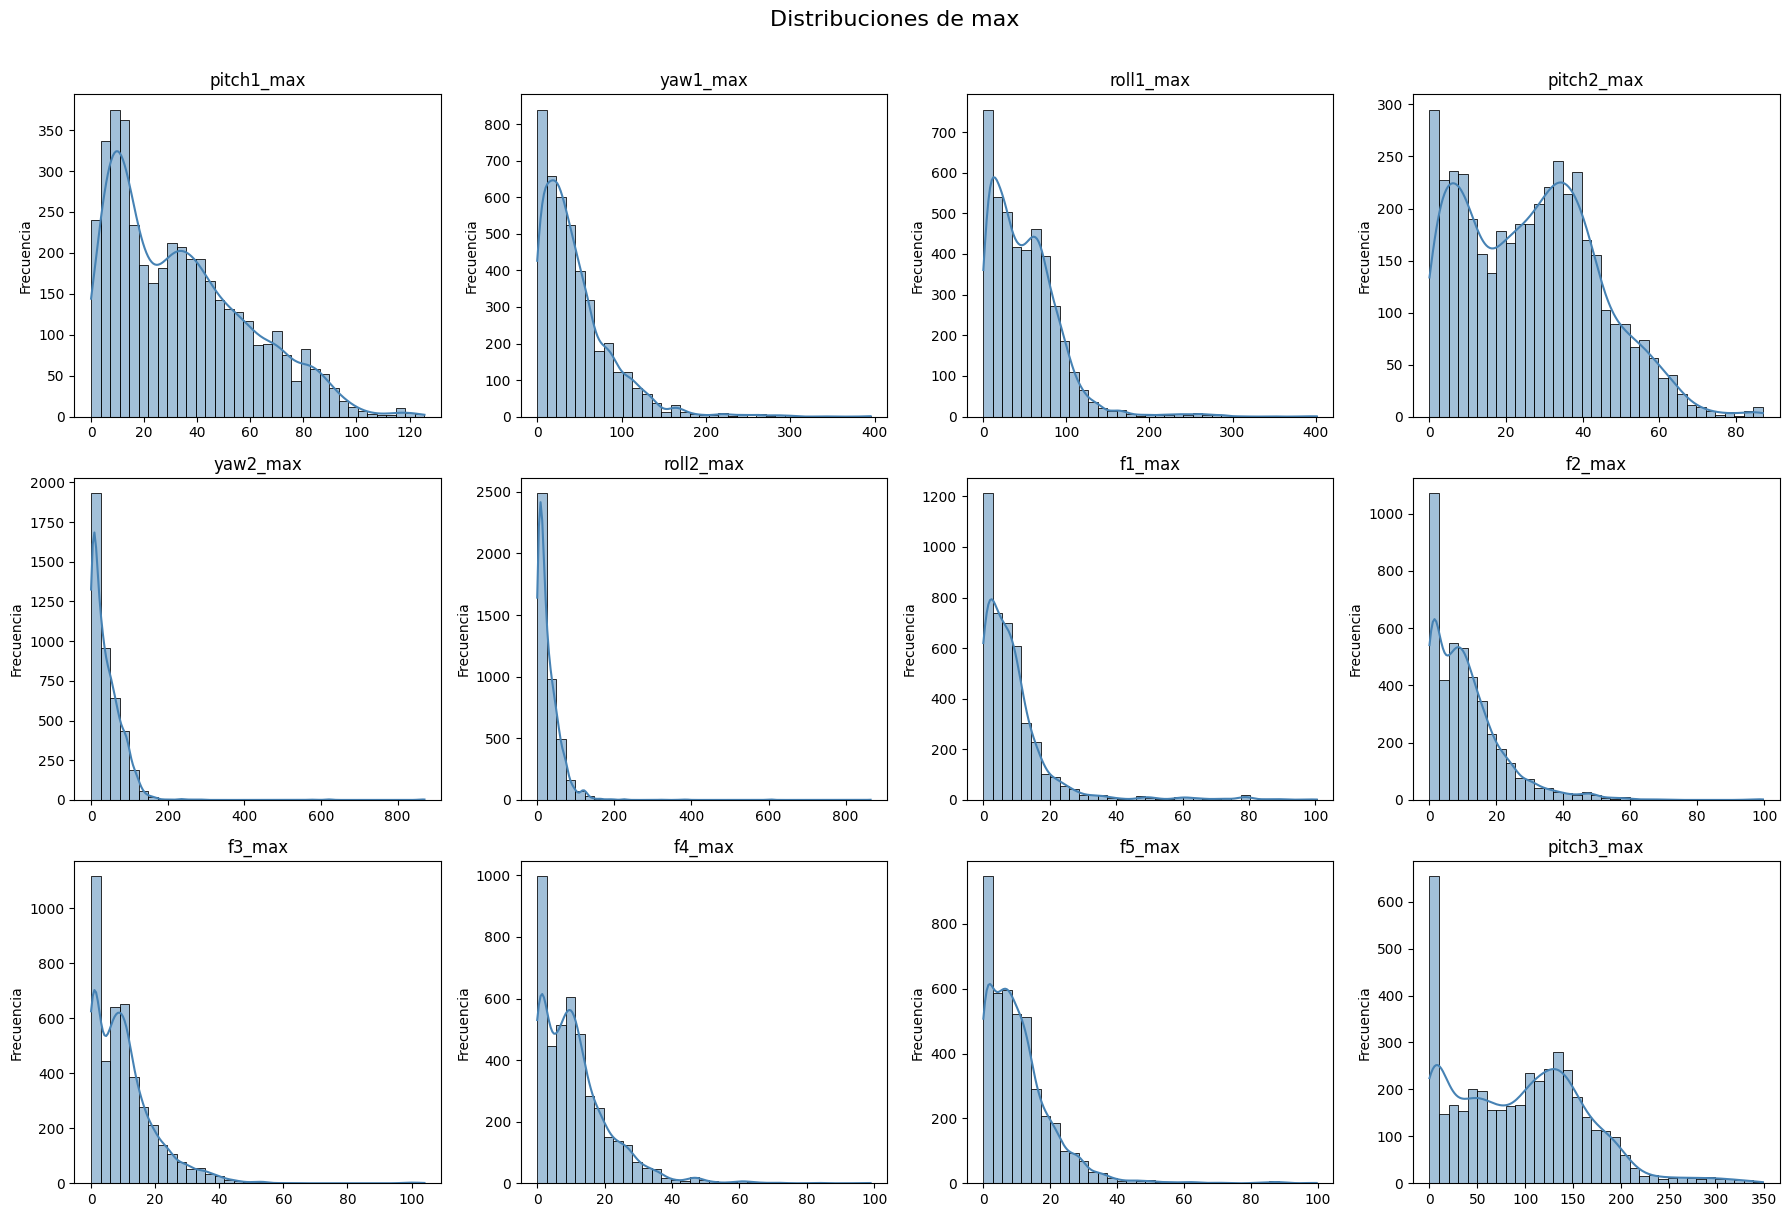

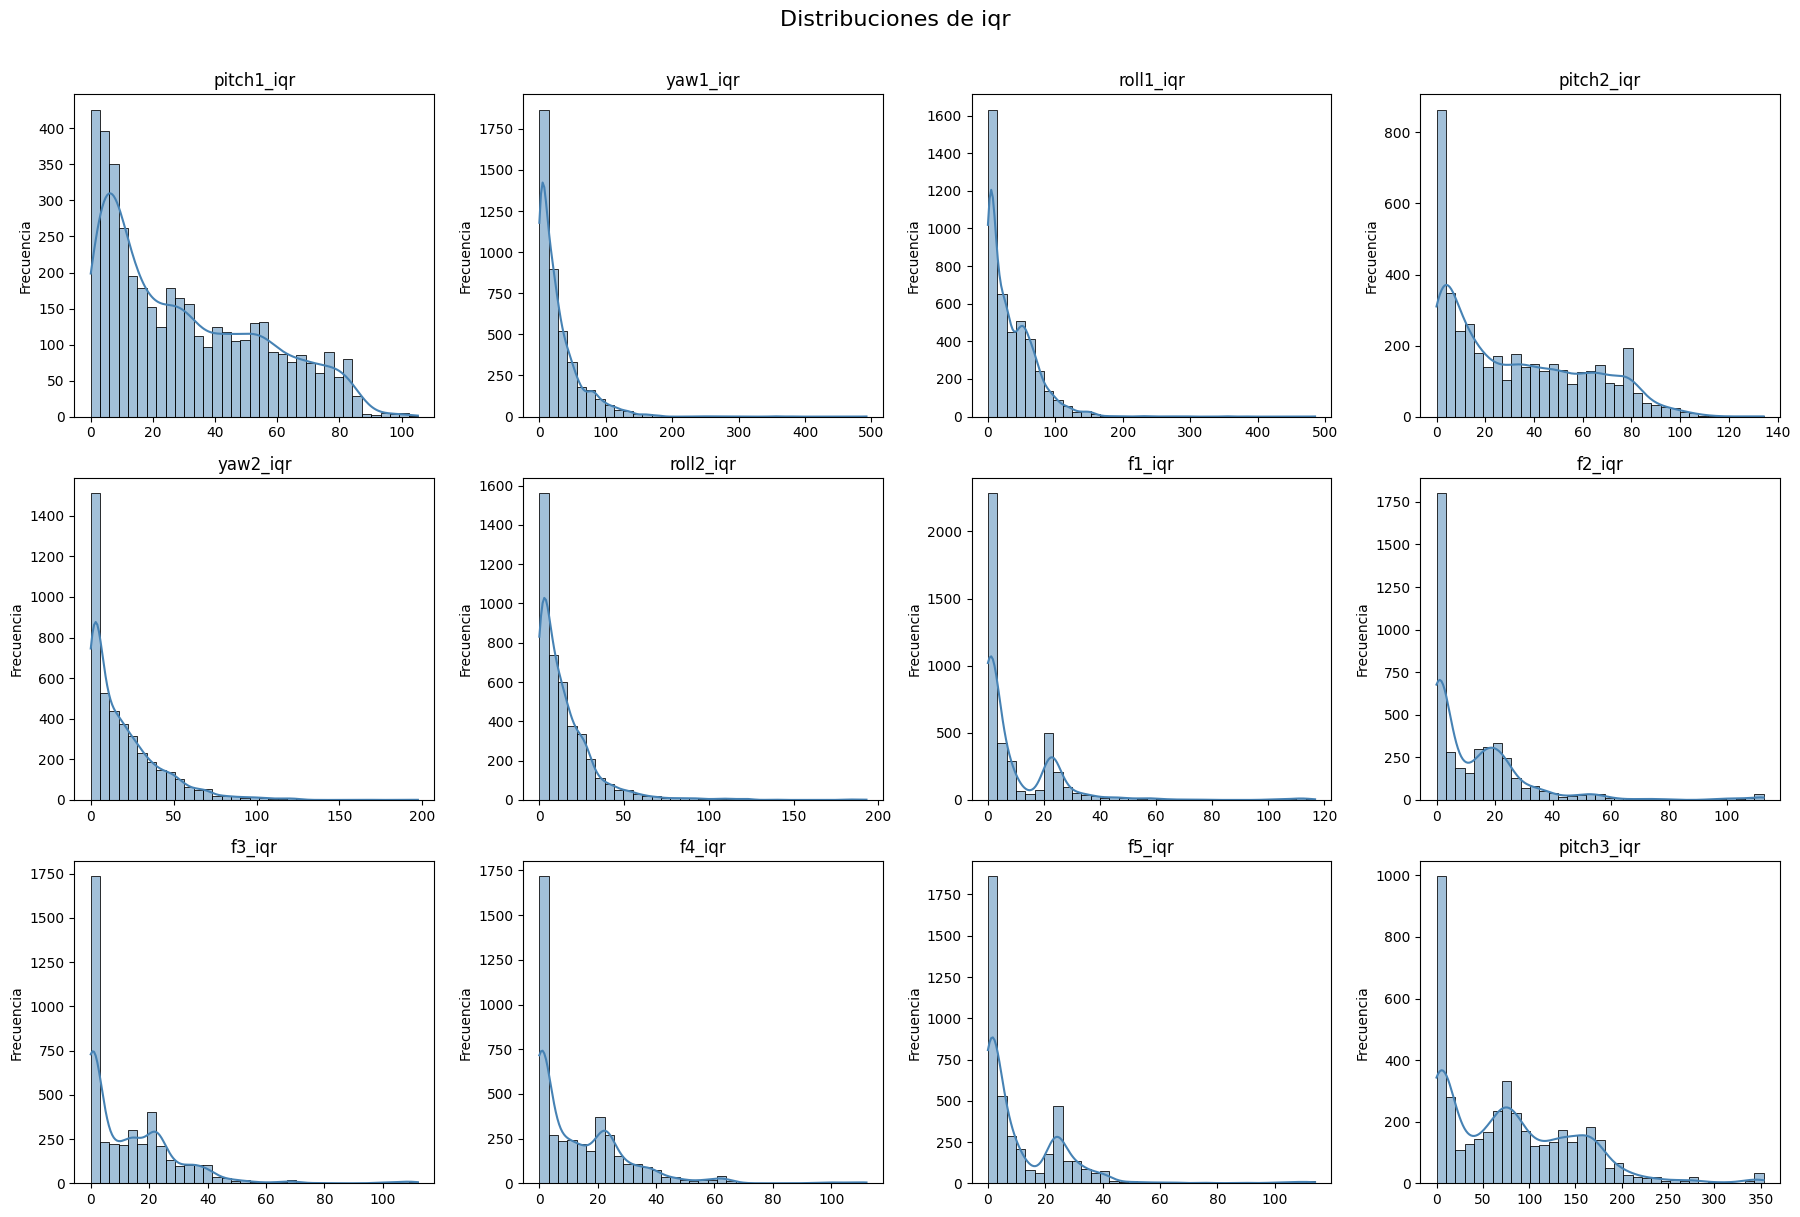

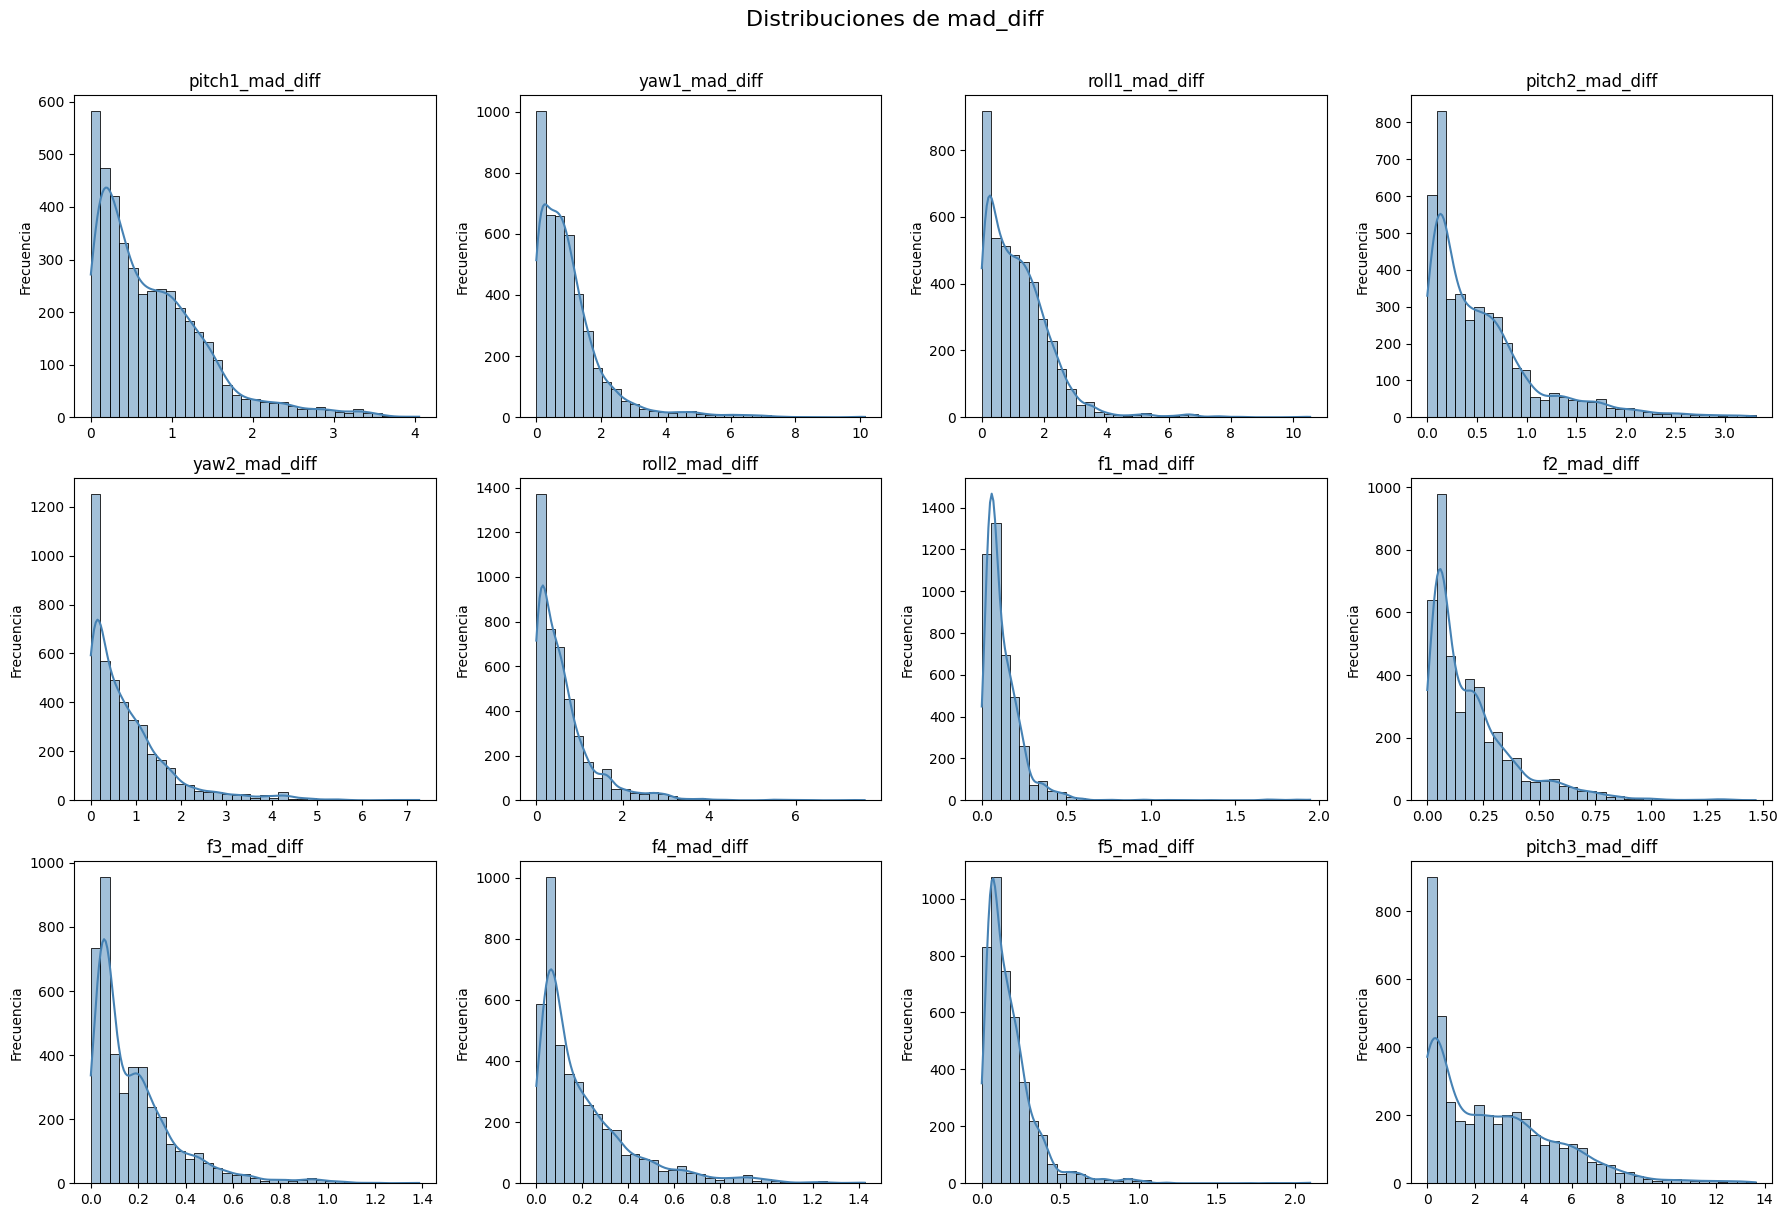

In [26]:
graficar_histogramas_estadistica(
    df_eda_reducido,
    "median"
)

graficar_histogramas_estadistica(
    df_eda_reducido,
    "min"
)

graficar_histogramas_estadistica(
    df_eda_reducido,
    "max"
)

graficar_histogramas_estadistica(
    df_eda_reducido,
    "iqr"
)

graficar_histogramas_estadistica(
    df_eda_reducido,
    "mad_diff"
)

In [27]:
def graficar_boxplots_estadistica(
    df,
    estadistica
):
    columnas = [
        f"{canal}_{estadistica}"
        for canal in canales
    ]

    datos_long = df[columnas].melt(
        var_name="caracteristica",
        value_name="valor"
    )

    plt.figure(figsize=(16, 6))

    sns.boxplot(
        data=datos_long,
        x="caracteristica",
        y="valor",
        showfliers=False,
        color="lightblue"
    )

    plt.title(
        f"Dispersión global de {estadistica} por canal"
    )
    plt.xlabel("")
    plt.ylabel("Valor")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

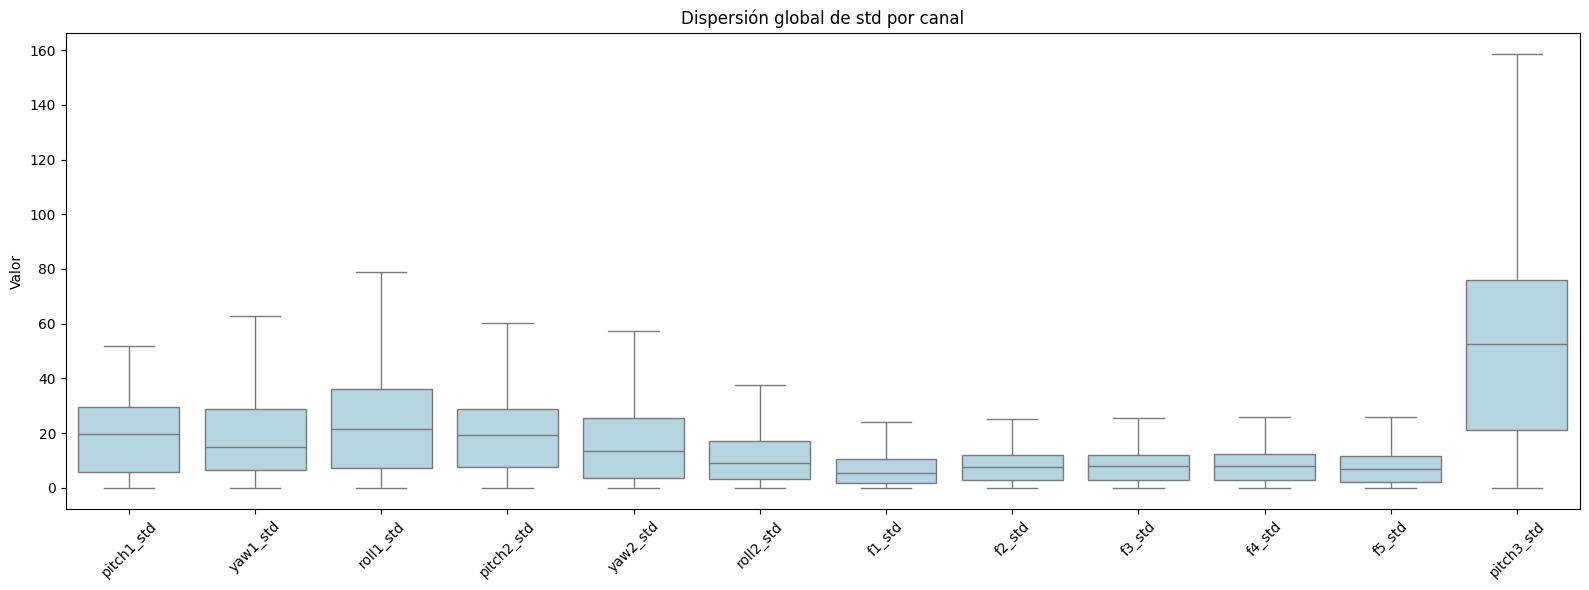

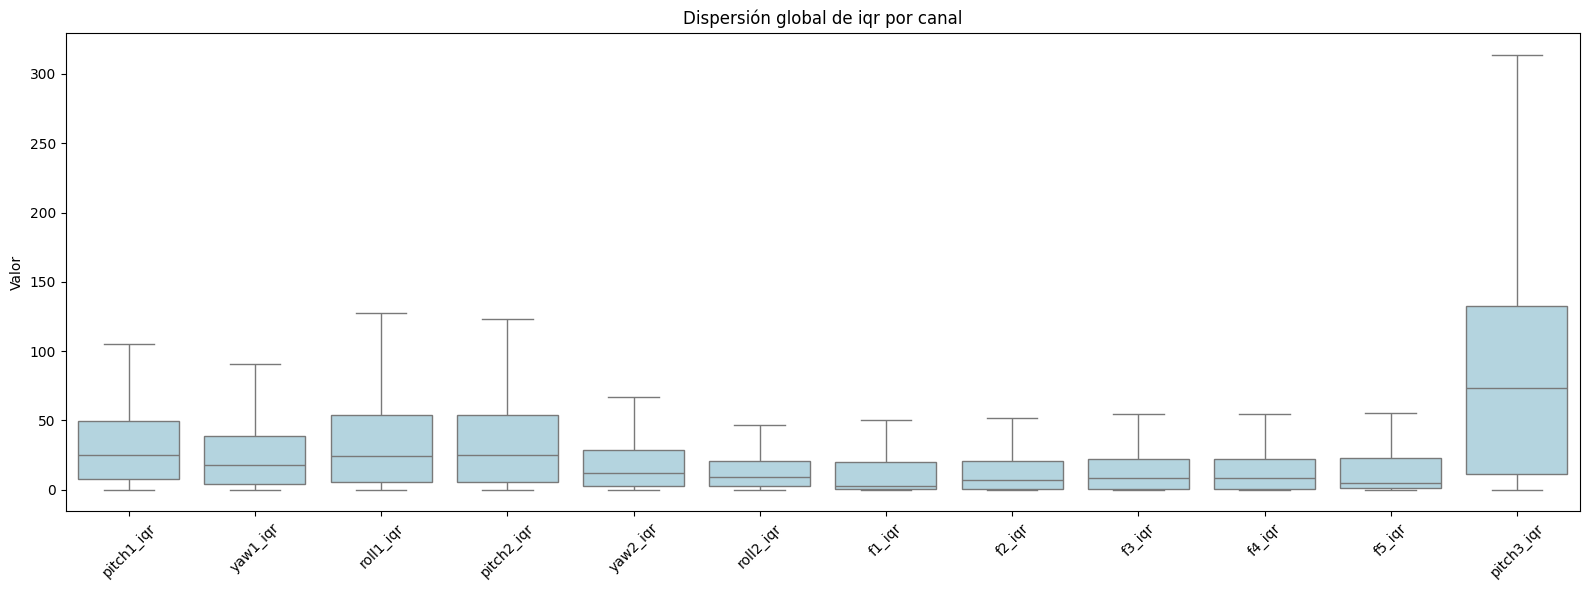

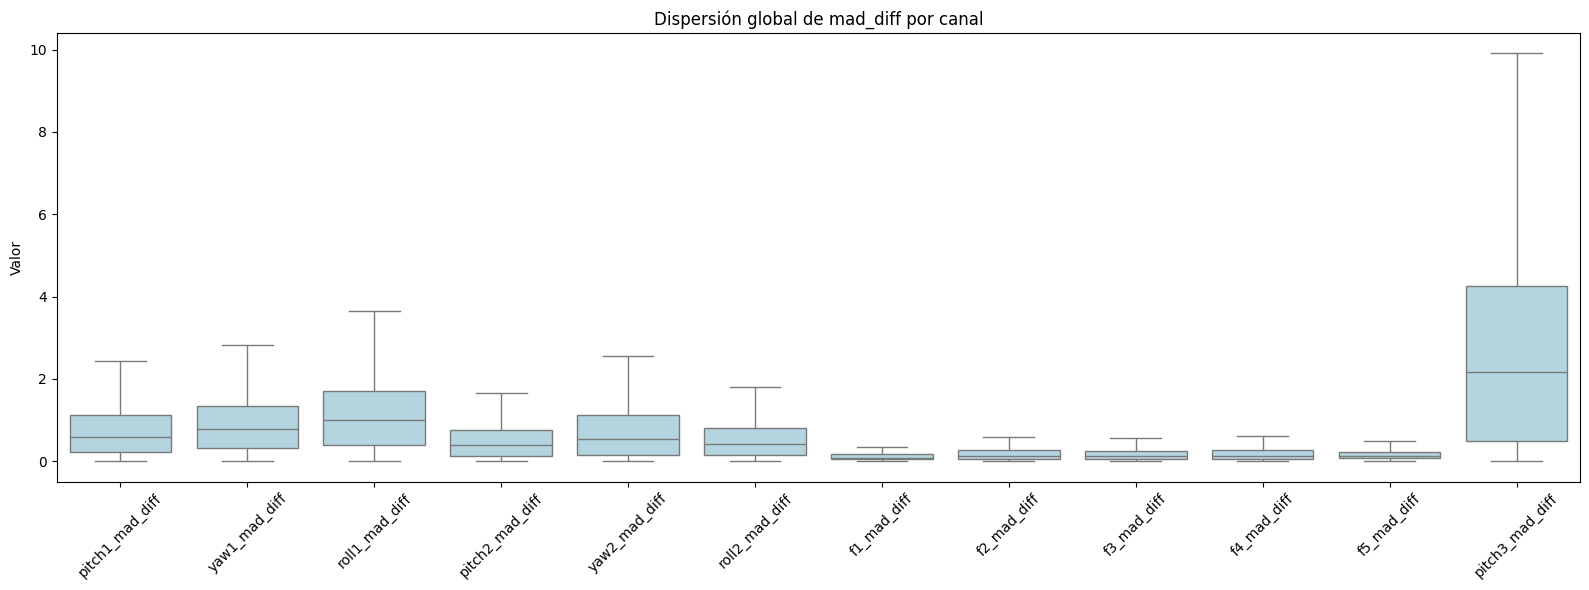

In [28]:
graficar_boxplots_estadistica(
    df_eda_reducido,
    "std"
)

graficar_boxplots_estadistica(
    df_eda_reducido,
    "iqr"
)

graficar_boxplots_estadistica(
    df_eda_reducido,
    "mad_diff"
)

In [29]:
resumen_outliers = []

for feature in features_reducidas:

    serie = df_eda_reducido[
        feature
    ].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_outlier = (
        (serie < limite_inferior)
        | (serie > limite_superior)
    )

    resumen_outliers.append({
        "caracteristica": feature,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "n_outliers": mascara_outlier.sum(),
        "porcentaje_outliers": (
            100 * mascara_outlier.mean()
        )
    })

resumen_outliers = (
    pd.DataFrame(resumen_outliers)
    .sort_values(
        "porcentaje_outliers",
        ascending=False
    )
)

display(resumen_outliers.head(25))

,caracteristica,limite_inferior,limite_superior,n_outliers,porcentaje_outliers
25,yaw2_median,-7.415851,6.569338,925,21.728917
31,roll2_median,-5.061591,5.423433,833,19.567771
7,yaw1_median,-10.626354,9.674231,686,16.114635
13,roll1_median,-13.126188,12.886290,589,13.836035
19,pitch2_median,-17.112742,22.432713,521,12.238666
1,pitch1_median,-14.269517,14.229059,488,11.463472
43,f2_median,-7.257955,12.096591,412,9.678177
37,f1_median,-7.059489,11.367330,410,9.631196
55,f4_median,-7.452614,12.421023,404,9.490251
49,f3_median,-6.908807,11.539830,386,9.067418


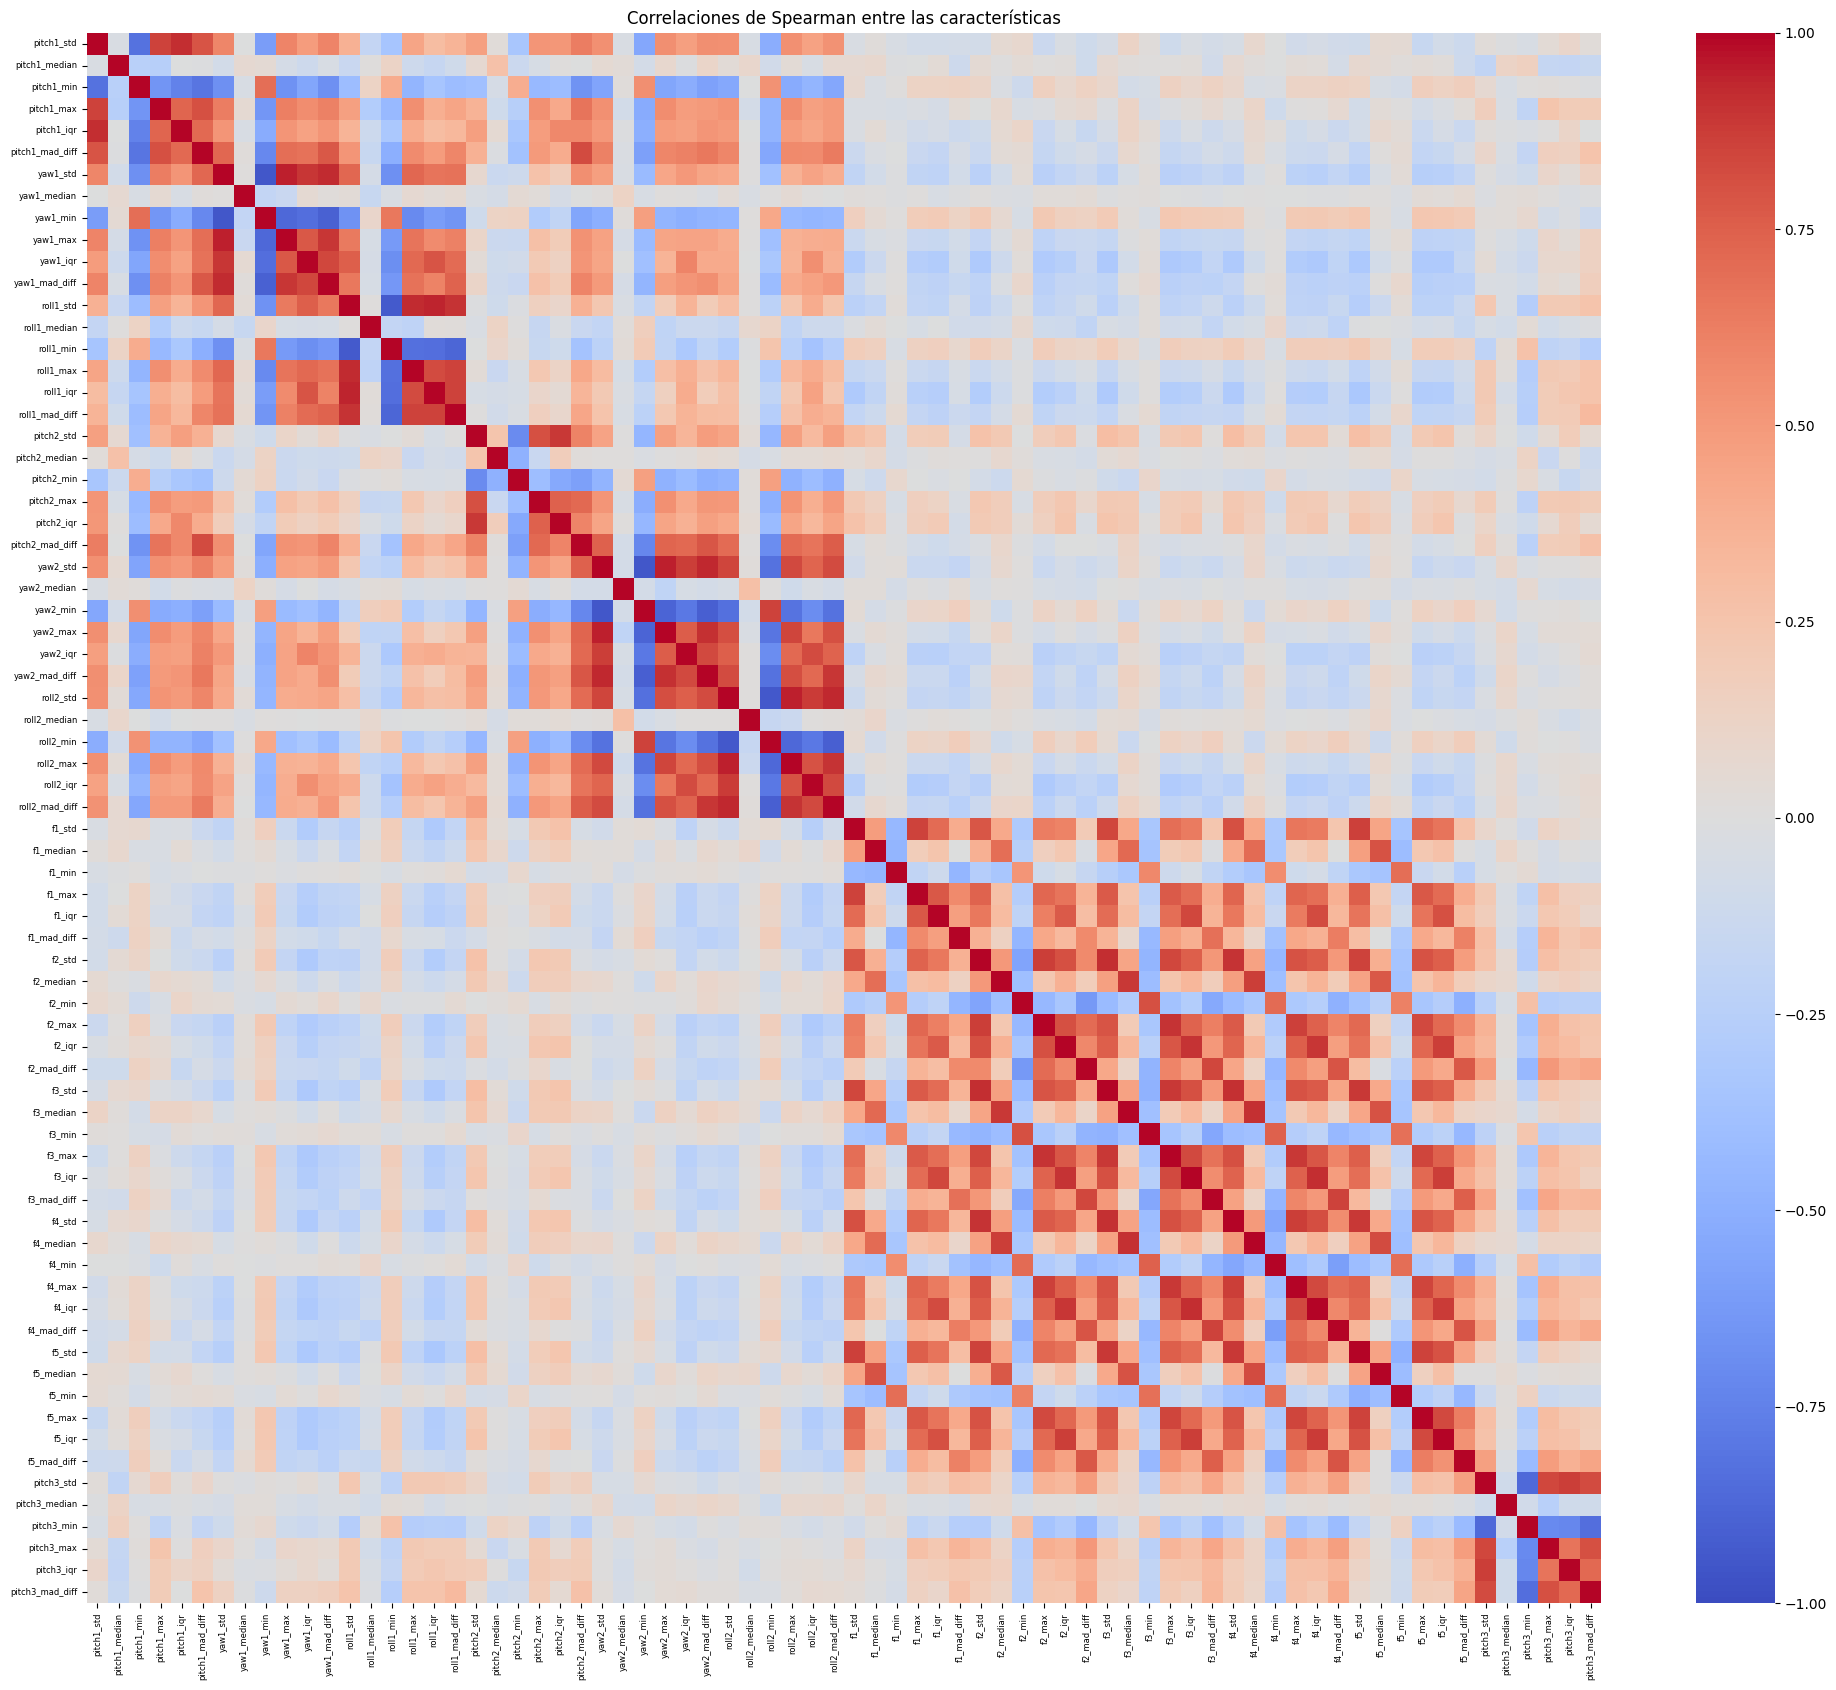

In [30]:
corr_spearman = (
    df_eda_reducido[features_reducidas]
    .corr(method="spearman")
)

plt.figure(figsize=(20, 17))

sns.heatmap(
    corr_spearman,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=True,
    yticklabels=True
)

plt.title(
    "Correlaciones de Spearman entre las características"
)

plt.xticks(
    rotation=90,
    fontsize=6
)

plt.yticks(
    rotation=0,
    fontsize=6
)

plt.tight_layout()
plt.show()

In [31]:
corr_abs = corr_spearman.abs()

mascara_superior = np.triu(
    np.ones(corr_abs.shape),
    k=1
).astype(bool)

pares_correlacionados = (
    corr_abs
    .where(mascara_superior)
    .stack()
    .reset_index()
)

pares_correlacionados.columns = [
    "caracteristica_1",
    "caracteristica_2",
    "correlacion_absoluta"
]

pares_correlacionados = (
    pares_correlacionados[
        pares_correlacionados[
            "correlacion_absoluta"
        ] >= 0.90
    ]
    .sort_values(
        "correlacion_absoluta",
        ascending=False
    )
)

display(pares_correlacionados.head(40))

,caracteristica_1,caracteristica_2,correlacion_absoluta
1697,roll2_std,roll2_max,0.950655
412,yaw1_std,yaw1_min,0.948967
1430,yaw2_std,yaw2_max,0.948384
1429,yaw2_std,yaw2_min,0.947337
413,yaw1_std,yaw1_max,0.945479
1696,roll2_std,roll2_min,0.942174
789,roll1_std,roll1_iqr,0.938858
1432,yaw2_std,yaw2_mad_diff,0.934323
787,roll1_std,roll1_min,0.933667
1699,roll2_std,roll2_mad_diff,0.930509


In [32]:
medias_movimiento = (
    df_eda_reducido
    .groupby(
        "movimiento",
        observed=True
    )[features_reducidas]
    .mean()
)

media_global = (
    df_eda_reducido[features_reducidas]
    .mean()
)

std_global = (
    df_eda_reducido[features_reducidas]
    .std()
    .replace(0, np.nan)
)

medias_movimiento_z = (
    medias_movimiento
    - media_global
) / std_global

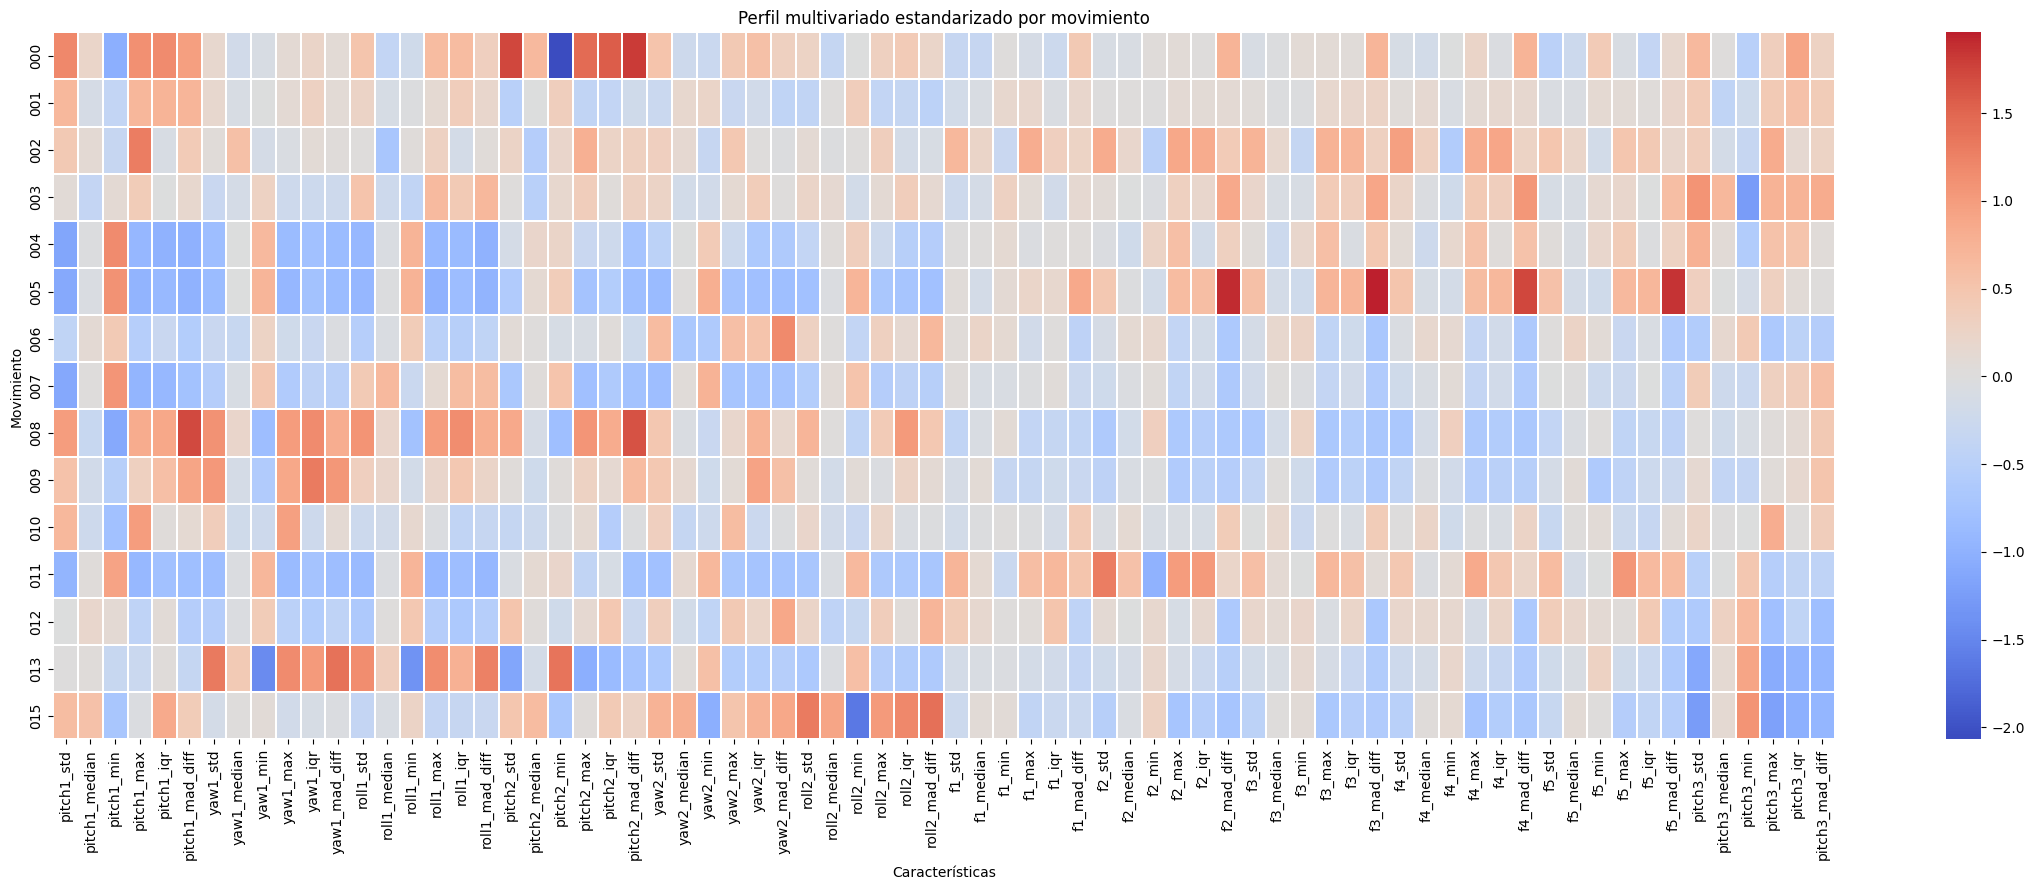

In [33]:
plt.figure(figsize=(23, 9))

sns.heatmap(
    medias_movimiento_z,
    cmap="coolwarm",
    center=0,
    linewidths=0.15
)

plt.title(
    "Perfil multivariado estandarizado por movimiento"
)
plt.xlabel("Características")
plt.ylabel("Movimiento")
plt.tight_layout()
plt.show()

In [35]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

X_interacciones = (
    df_eda_reducido[features_reducidas]
    .copy()
)

y_interacciones = (
    df_eda_reducido["movimiento"]
    .astype(str)
)

# Convertimos las etiquetas a valores numéricos
label_encoder = LabelEncoder()

y_codificada = label_encoder.fit_transform(
    y_interacciones
)

informacion_mutua = mutual_info_classif(
    X_interacciones,
    y_codificada,
    random_state=42
)

ranking_mi = (
    pd.DataFrame({
        "caracteristica": features_reducidas,
        "informacion_mutua": informacion_mutua
    })
    .sort_values(
        "informacion_mutua",
        ascending=False
    )
    .reset_index(drop=True)
)

display(ranking_mi.head(20))

,caracteristica,informacion_mutua
0,pitch1_mad_diff,1.013525
1,yaw1_std,0.992711
2,pitch2_mad_diff,0.955367
3,yaw1_max,0.948125
4,yaw1_min,0.917300
5,f2_mad_diff,0.891695
6,pitch3_std,0.890187
7,roll1_std,0.888034
8,pitch2_iqr,0.869597
9,f3_mad_diff,0.869539


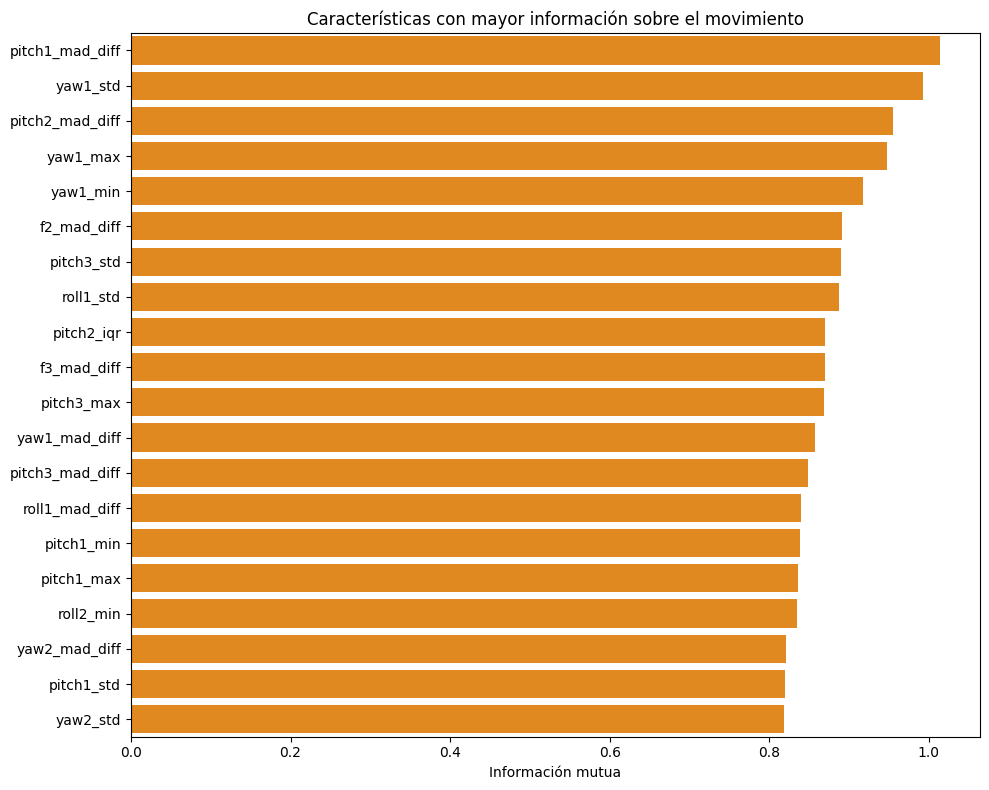

In [36]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=ranking_mi.head(20),
    x="informacion_mutua",
    y="caracteristica",
    color="darkorange"
)

plt.title(
    "Características con mayor información sobre el movimiento"
)
plt.xlabel("Información mutua")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [37]:
corr_interacciones = (
    df_eda_reducido[features_reducidas]
    .corr(method="spearman")
    .abs()
)

features_interaccion = []

for feature in ranking_mi["caracteristica"]:

    if len(features_interaccion) == 0:
        features_interaccion.append(feature)

    else:
        correlaciones_previas = [
            corr_interacciones.loc[
                feature,
                seleccionada
            ]
            for seleccionada in features_interaccion
        ]

        if all(
            correlacion < 0.75
            for correlacion in correlaciones_previas
        ):
            features_interaccion.append(feature)

    if len(features_interaccion) == 4:
        break

print(
    "Características seleccionadas:"
)

for feature in features_interaccion:
    mi_feature = ranking_mi.loc[
        ranking_mi["caracteristica"] == feature,
        "informacion_mutua"
    ].iloc[0]

    print(
        f"- {feature}: "
        f"MI = {mi_feature:.4f}"
    )

Características seleccionadas:
- pitch1_mad_diff: MI = 1.0135
- yaw1_std: MI = 0.9927
- f2_mad_diff: MI = 0.8917
- pitch3_std: MI = 0.8902


In [38]:
display(
    df_eda_reducido[
        features_interaccion
    ]
    .corr(method="spearman")
    .round(3)
)

,pitch1_mad_diff,yaw1_std,f2_mad_diff,pitch3_std
pitch1_mad_diff,1.000,0.719,-0.060,0.098
yaw1_std,0.719,1.000,-0.130,0.006
f2_mad_diff,-0.060,-0.130,1.000,0.486
pitch3_std,0.098,0.006,0.486,1.000


In [40]:
partes = []

for movimiento, grupo in df_eda_reducido.groupby(
    "movimiento",
    observed=True
):
    partes.append(
        grupo[columnas_pairplot].sample(
            n=min(120, len(grupo)),
            random_state=42
        )
    )

muestra_pairplot = pd.concat(
    partes,
    ignore_index=True
)

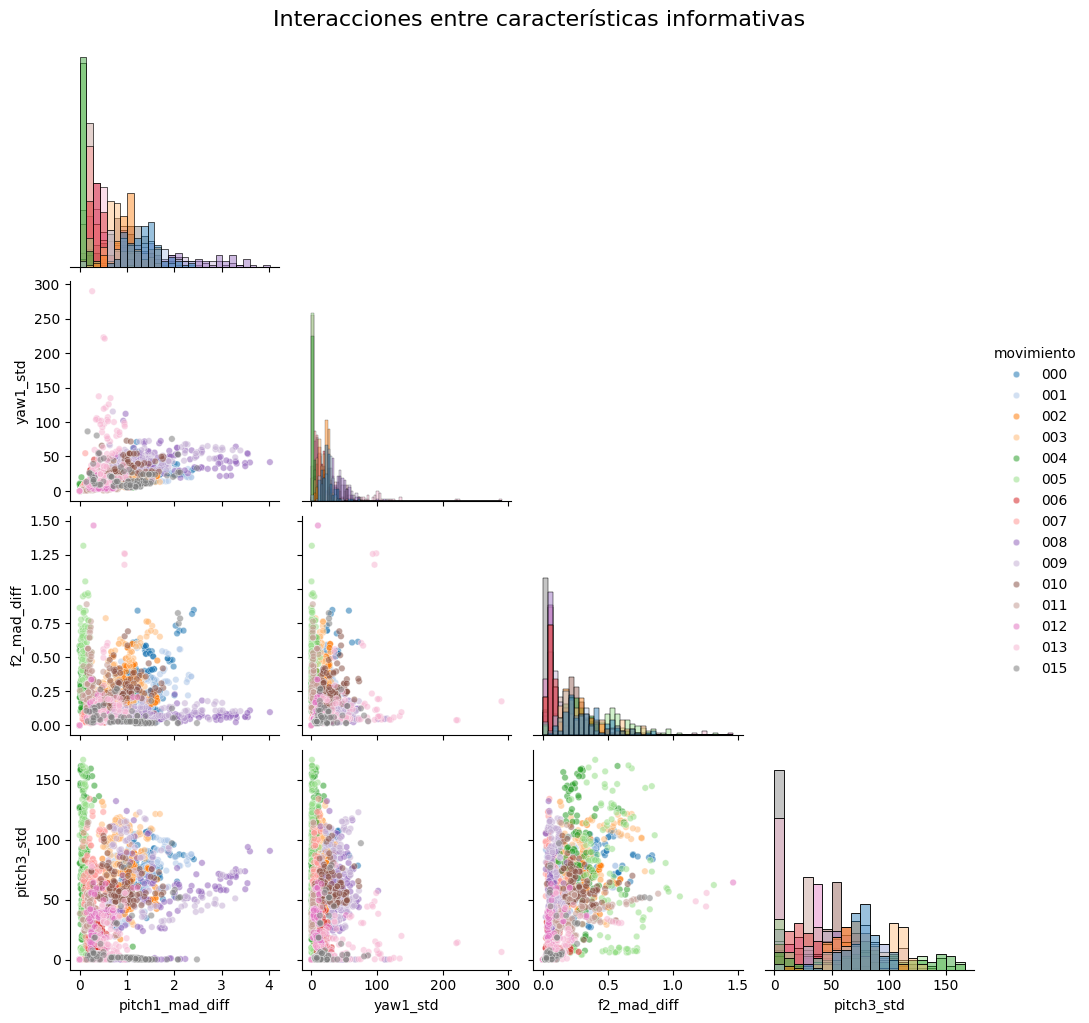

In [41]:
g = sns.pairplot(
    data=muestra_pairplot,
    vars=features_interaccion,
    hue="movimiento",
    palette="tab20",
    corner=True,
    diag_kind="hist",
    plot_kws={
        "alpha": 0.55,
        "s": 22
    },
    diag_kws={
        "alpha": 0.45
    }
)

g.fig.suptitle(
    "Interacciones entre características informativas",
    y=1.02,
    fontsize=16
)

plt.show()

In [42]:
feature_x = features_interaccion[0]
feature_y = features_interaccion[1]

In [43]:
centroides = (
    df_eda_reducido
    .groupby(
        "movimiento",
        observed=True
    )[
        [feature_x, feature_y]
    ]
    .mean()
    .reset_index()
)

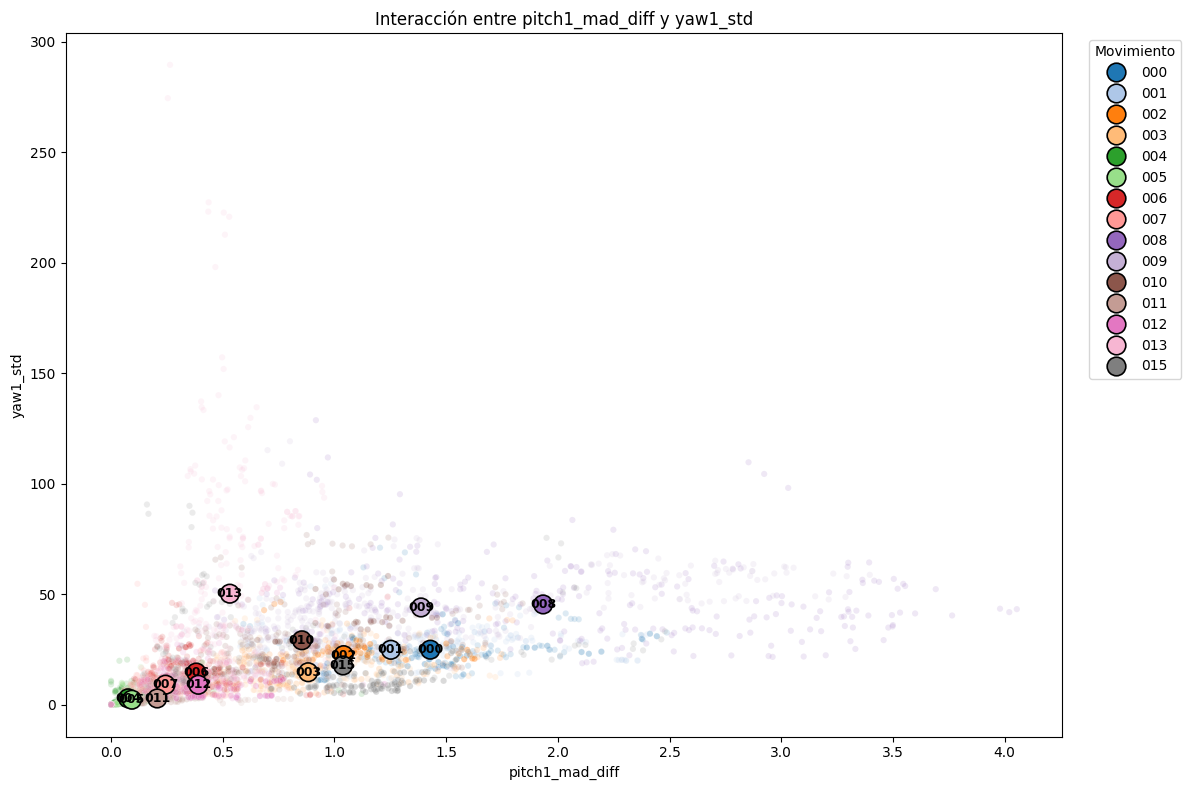

In [44]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_eda_reducido,
    x=feature_x,
    y=feature_y,
    hue="movimiento",
    palette="tab20",
    alpha=0.15,
    s=20,
    legend=False
)

sns.scatterplot(
    data=centroides,
    x=feature_x,
    y=feature_y,
    hue="movimiento",
    palette="tab20",
    s=180,
    edgecolor="black",
    linewidth=1.2
)

for _, fila in centroides.iterrows():
    plt.text(
        fila[feature_x],
        fila[feature_y],
        str(fila["movimiento"]),
        fontsize=9,
        fontweight="bold",
        ha="center",
        va="center"
    )

plt.title(
    f"Interacción entre {feature_x} y {feature_y}"
)
plt.legend(
    title="Movimiento",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

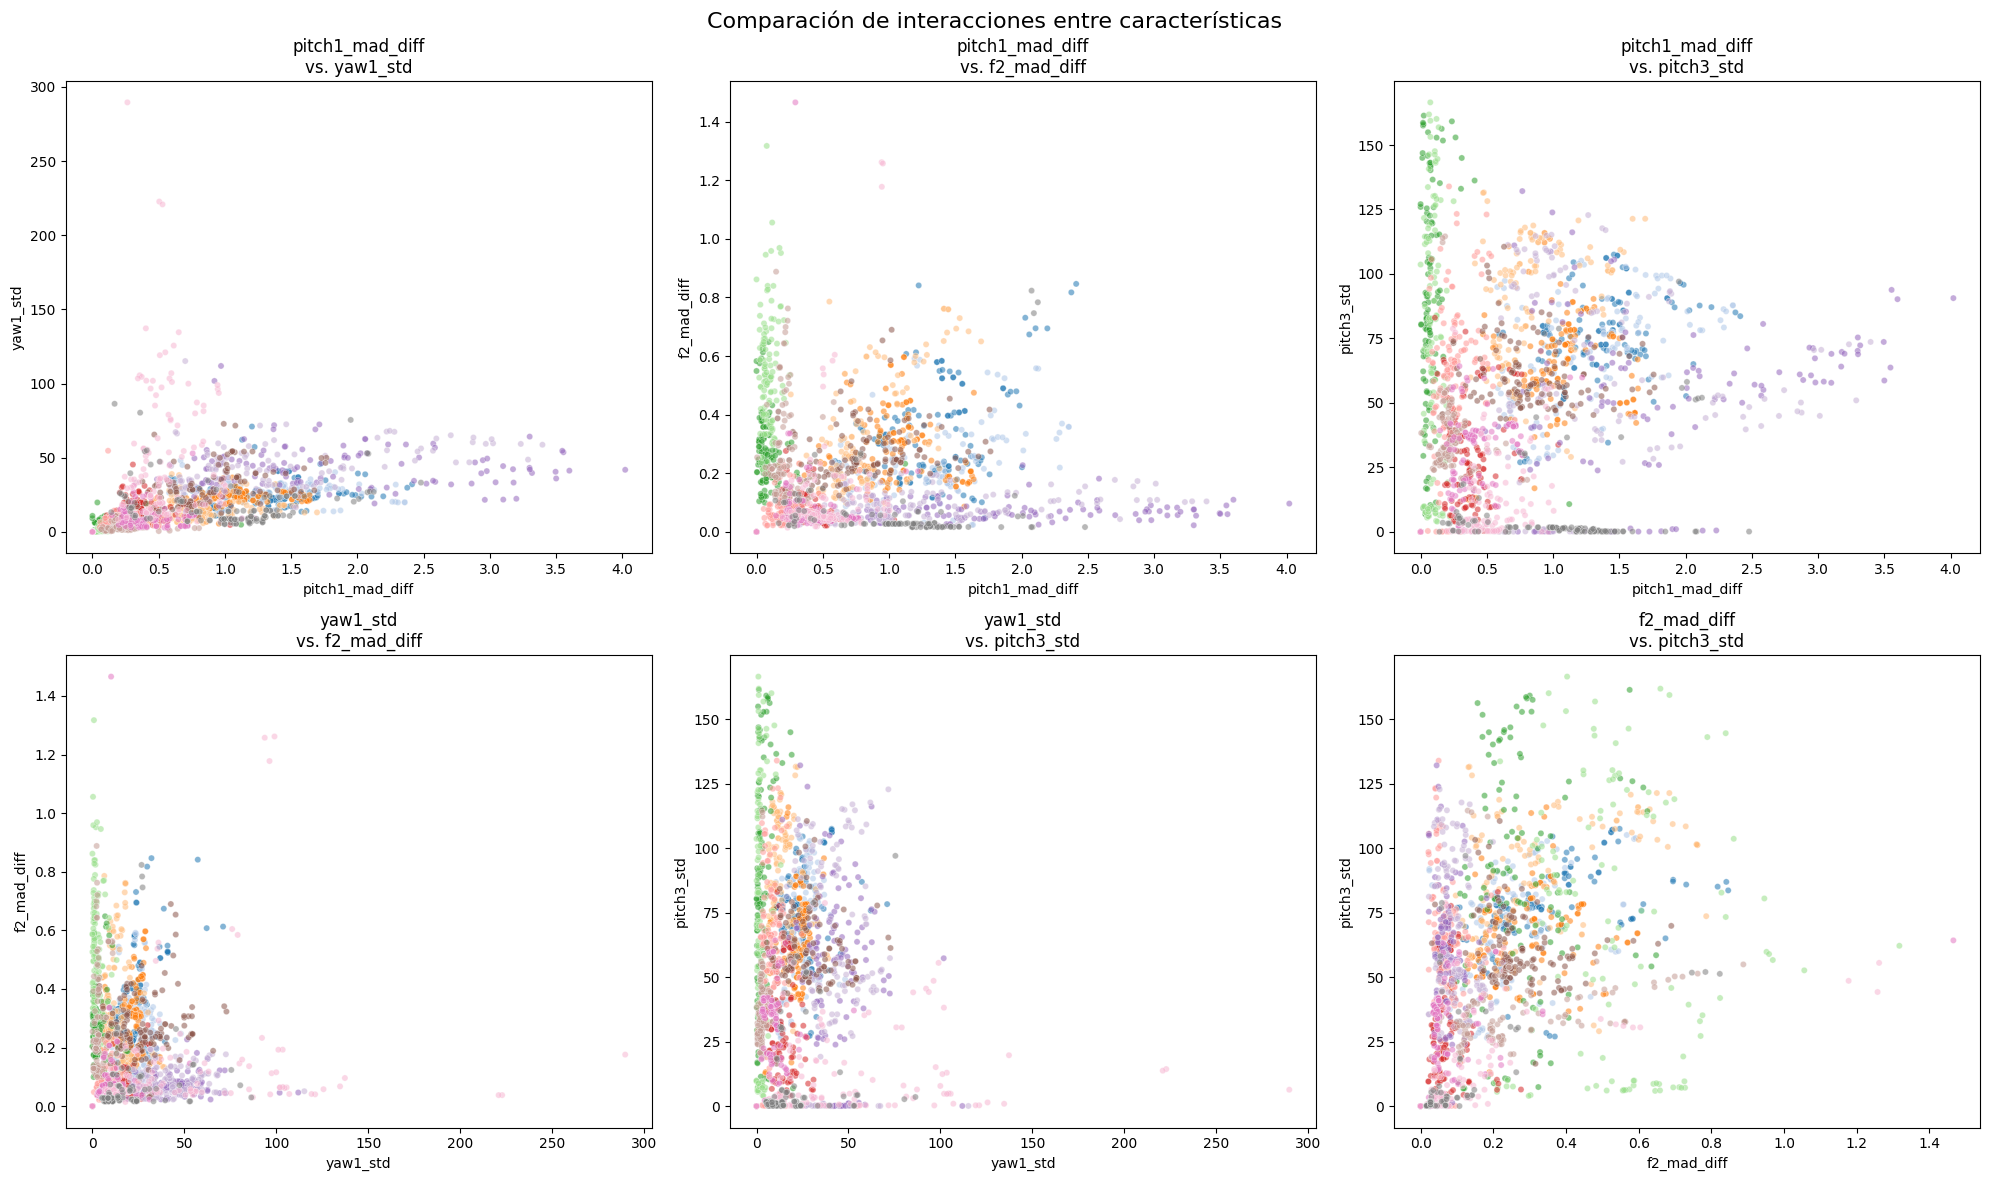

In [45]:
from itertools import combinations

pares_features = list(
    combinations(
        features_interaccion,
        2
    )
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(20, 12)
)

axes = axes.flatten()

for ax, (feature_x, feature_y) in zip(
    axes,
    pares_features
):
    sns.scatterplot(
        data=muestra_pairplot,
        x=feature_x,
        y=feature_y,
        hue="movimiento",
        palette="tab20",
        alpha=0.55,
        s=20,
        legend=False,
        ax=ax
    )

    ax.set_title(
        f"{feature_x}\nvs. {feature_y}"
    )

plt.suptitle(
    "Comparación de interacciones entre características",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

modelo_interaccion = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

In [47]:
def comparar_interaccion(
    df,
    feature_1,
    feature_2
):
    y = df["movimiento"].astype(str)

    resultados = []

    conjuntos = {
        feature_1: [feature_1],
        feature_2: [feature_2],
        "combinacion": [
            feature_1,
            feature_2
        ]
    }

    for nombre, columnas in conjuntos.items():

        scores = cross_val_score(
            modelo_interaccion,
            df[columnas],
            y,
            cv=cv,
            scoring="f1_macro",
            n_jobs=-1
        )

        resultados.append({
            "variables": nombre,
            "f1_macro_promedio": scores.mean(),
            "desviacion": scores.std()
        })

    return pd.DataFrame(resultados)

In [48]:
resultados_interacciones = []

for feature_1, feature_2 in pares_features:

    resultado = comparar_interaccion(
        df_eda_reducido,
        feature_1,
        feature_2
    )

    resultado["feature_1"] = feature_1
    resultado["feature_2"] = feature_2

    resultados_interacciones.append(
        resultado
    )

resultados_interacciones = pd.concat(
    resultados_interacciones,
    ignore_index=True
)

display(resultados_interacciones)

,variables,f1_macro_promedio,desviacion,feature_1,feature_2
0,pitch1_mad_diff,0.223700,0.010735,pitch1_mad_diff,yaw1_std
1,yaw1_std,0.223643,0.012931,pitch1_mad_diff,yaw1_std
2,combinacion,0.325346,0.011548,pitch1_mad_diff,yaw1_std
3,pitch1_mad_diff,0.223700,0.010735,pitch1_mad_diff,f2_mad_diff
4,f2_mad_diff,0.203932,0.013334,pitch1_mad_diff,f2_mad_diff
5,combinacion,0.398378,0.029423,pitch1_mad_diff,f2_mad_diff
6,pitch1_mad_diff,0.223700,0.010735,pitch1_mad_diff,pitch3_std
7,pitch3_std,0.257516,0.009424,pitch1_mad_diff,pitch3_std
8,combinacion,0.340957,0.016963,pitch1_mad_diff,pitch3_std
9,yaw1_std,0.223643,0.012931,yaw1_std,f2_mad_diff
